# 🔬 HAM10000 / ISIC 2018 — Exploratory Data Analysis (EDA)

## Why do EDA before training?

**EDA is the most important step that most beginners skip.** Before building any model, you need to:

1. **Understand your data** — What format is it in? How many samples? What are the features?
2. **Find problems** — Missing values? Corrupted files? Class imbalance? Data leakage?
3. **Inform your training strategy** — Should you oversample? What augmentations make sense? What metrics to use?

Think of it like a doctor examining a patient before treatment. You wouldn't prescribe medicine without understanding the symptoms first.

### About the HAM10000 Dataset

The **HAM10000** ("Human Against Machine with 10000 training images") dataset is a large collection of **dermatoscopic images** — close-up photos of skin lesions taken with a special magnifying instrument called a dermatoscope. It was the primary dataset used in the **ISIC 2018 Challenge** (International Skin Imaging Collaboration).

The dataset contains **7 diagnostic categories**:
| Abbreviation | Full Name | Is It Cancer? |
|---|---|---|
| `nv` | Melanocytic nevi (moles) | No — benign |
| `mel` | Melanoma | **YES — malignant, deadliest skin cancer** |
| `bkl` | Benign keratosis | No — benign |
| `bcc` | Basal cell carcinoma | Yes — but rarely spreads |
| `akiec` | Actinic keratosis / Bowen's disease | Pre-cancerous |
| `vasc` | Vascular lesion | No — benign |
| `df` | Dermatofibroma | No — benign |

---

## Section 1: Setup & Imports

We start by importing libraries. Each one serves a specific purpose.

In [4]:
# ============================================================================
# CELL 1: Import Libraries
# ============================================================================
# RATIONALE: We import specific libraries for specific jobs:
#   - pandas: The #1 tool for structured data (CSV files, tables). Think of it
#     as Excel on steroids. We use it to load and analyze the metadata CSV.
#   - numpy: Numerical operations on arrays. When we load images, they become
#     numpy arrays of pixel values.
#   - matplotlib + seaborn: Visualization. matplotlib is the low-level engine,
#     seaborn makes it prettier with better defaults for statistical plots.
#   - PIL (Pillow): Image loading library. Reads JPG/PNG files into arrays.
#   - os, glob, pathlib: File system operations — finding files, checking paths.
#   - collections.Counter: Quick way to count occurrences (like counting how
#     many images per class).
#   - warnings: We suppress non-critical warnings so output stays clean.
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import glob
from pathlib import Path
from collections import Counter
import warnings

# Suppress non-critical warnings to keep output clean
warnings.filterwarnings('ignore')

# Set plot style — 'whitegrid' adds subtle gridlines that make reading values easier
# RATIONALE: seaborn styles give us publication-quality plots with minimal effort.
# 'whitegrid' is preferred for bar charts and distributions because the grid helps
# you compare bar heights visually.
sns.set_style('whitegrid')
sns.set_palette('husl')  # Perceptually uniform colors — important for accessibility

# Make plots larger by default so labels are readable
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [5]:
# ============================================================================
# CELL 2: Define Data Paths
# ============================================================================
# RATIONALE: We define ALL paths in ONE place at the top of the notebook.
# This is a best practice because:
#   1. If you move the data folder, you only change ONE variable.
#   2. Other people running this notebook can easily update the path.
#   3. Prevents typos — you type the path once, reference the variable everywhere.
#
# We also use pathlib.Path instead of raw strings because:
#   - It handles OS differences (Windows uses \, Linux uses /)
#   - It has useful methods like .exists(), .glob(), .name
#   - Path / 'subdir' is cleaner than os.path.join(path, 'subdir')
# ============================================================================

DATA_DIR = Path('/home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data')

# HAM10000 training data paths
METADATA_PATH = DATA_DIR / 'HAM10000_metadata'
IMAGES_PART1_DIR = DATA_DIR / 'HAM10000_images_part_1'
IMAGES_PART2_DIR = DATA_DIR / 'HAM10000_images_part_2'
SEGMENTATION_DIR = DATA_DIR / 'HAM10000_segmentations_lesion_tschandl' / 'HAM10000_segmentations_lesion_tschandl'

# ISIC 2018 test data paths
TEST_IMAGES_DIR = DATA_DIR / 'ISIC2018_Task3_Test_Images' / 'ISIC2018_Task3_Test_Images'
TEST_GT_PATH = DATA_DIR / 'ISIC2018_Task3_Test_GroundTruth.csv'

# Verify all critical paths exist
# RATIONALE: Failing fast is better than getting a cryptic error 100 lines later.
# This sanity check saves debugging time.
paths_to_check = {
    'Data' : DATA_DIR, 
    'Metadata CSV': METADATA_PATH,
    'Images Part 1': IMAGES_PART1_DIR,
    'Images Part 2': IMAGES_PART2_DIR,
    'Segmentation Masks': SEGMENTATION_DIR,
    'Test Images': TEST_IMAGES_DIR,
    'Test Ground Truth': TEST_GT_PATH,
}

print('📂 Data Path Verification:')
print('=' * 60)
all_ok = True
for name, path in paths_to_check.items():
    exists = path.exists()
    status = '✅' if exists else '❌ MISSING'
    print(f'  {status} {name}: {path}')
    if not exists:
        all_ok = False

if all_ok:
    print('\n✅ All data paths verified!')
else:
    print('\n⚠️ Some paths are missing — check your data download!')

📂 Data Path Verification:
  ✅ Data: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data
  ✅ Metadata CSV: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/HAM10000_metadata
  ✅ Images Part 1: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/HAM10000_images_part_1
  ✅ Images Part 2: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/HAM10000_images_part_2
  ✅ Segmentation Masks: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/HAM10000_segmentations_lesion_tschandl/HAM10000_segmentations_lesion_tschandl
  ✅ Test Images: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/ISIC2018_Task3_Test_Images/ISIC2018_Task3_Test_Images
  ✅ Test Ground Truth: /home/chanduu/OSS/hiperhealth/hph-medvision-channel/training/data/ISIC2018_Task3_Test_GroundTruth.csv

✅ All data paths verified!


---
## Section 2: Data Inventory — What Do We Actually Have?

Before analyzing content, we need to know the **shape** of our data:
- How many files?
- What formats?
- Any corrupted files?

This is like counting inventory before opening a store.

In [6]:
# ============================================================================
# CELL 3: Count Images in Each Directory
# ============================================================================
# RATIONALE: We need to verify how many actual image files we have.
# The data was downloaded in two parts (HAM10000 was split for download).
# We need to check:
#   1. Do part 1 + part 2 add up to the expected ~10,015 images?
#   2. Are there any non-image files mixed in? (Zone.Identifier files from Windows)
#   3. Do we have a 1:1 mapping between images and metadata rows?
# ============================================================================

def count_files(directory, extension='.jpg'):
    """Count files with a specific extension in a directory.
    
    WHY a function? We'll call this multiple times for different directories.
    DRY principle (Don't Repeat Yourself) — write once, use everywhere.
    """
    files = list(Path(directory).glob(f'*{extension}'))
    return files

# Count training images
part1_images = count_files(IMAGES_PART1_DIR, '.jpg')
part2_images = count_files(IMAGES_PART2_DIR, '.jpg')
all_train_images = part1_images + part2_images

# Count segmentation masks
seg_masks = count_files(SEGMENTATION_DIR, '.png')

# Count test images
test_images = count_files(TEST_IMAGES_DIR, '.jpg')

print('📊 Data Inventory')
print('=' * 60)
print(f'Training Images (Part 1):     {len(part1_images):,}')
print(f'Training Images (Part 2):     {len(part2_images):,}')
print(f'Total Training Images:        {len(all_train_images):,}')
print(f'Segmentation Masks:           {len(seg_masks):,}')
print(f'Test Images:                  {len(test_images):,}')
print(f'\nTotal images in dataset:      {len(all_train_images) + len(test_images):,}')

# INSIGHT CHECK: Do images match segmentation masks?
# RATIONALE: If counts don't match, we might have corrupted downloads
# or missing masks. Segmentation masks are optional for classification,
# but useful for understanding which region of the image matters.
print(f'\n🔍 Integrity Check:')
print(f'  Images vs Masks: {len(all_train_images)} images, {len(seg_masks)} masks')
if len(all_train_images) == len(seg_masks):
    print(f'  ✅ Perfect 1:1 match!')
else:
    print(f'  ⚠️ Mismatch! Difference: {abs(len(all_train_images) - len(seg_masks))}')

📊 Data Inventory
Training Images (Part 1):     5,000
Training Images (Part 2):     5,015
Total Training Images:        10,015
Segmentation Masks:           10,015
Test Images:                  1,511

Total images in dataset:      11,526

🔍 Integrity Check:
  Images vs Masks: 10015 images, 10015 masks
  ✅ Perfect 1:1 match!


In [7]:
# ============================================================================
# CELL 4: Build a Master Image Index
# ============================================================================
# RATIONALE: We need a way to look up the file path for any image by its ID.
# The metadata CSV has image_id like 'ISIC_0027419' but the images are split
# across two directories. Building a dictionary (image_id → file_path) lets
# us quickly find any image.
#
# WHY a dictionary? O(1) lookup time. If we searched through a list each time,
# it would be O(n) × number of lookups = painfully slow for 10K images.
# ============================================================================

image_path_map = {}

for img_path in all_train_images:
    # Extract image_id from filename: 'ISIC_0027419.jpg' → 'ISIC_0027419'
    image_id = img_path.stem  # .stem gives filename without extension
    image_path_map[image_id] = img_path

print(f'📋 Image index built: {len(image_path_map):,} images indexed')
print(f'   Sample entries:')
for i, (k, v) in enumerate(list(image_path_map.items())[:3]):
    print(f'   {k} → {v.name} (in {v.parent.name})')

📋 Image index built: 10,015 images indexed
   Sample entries:
   ISIC_0024666 → ISIC_0024666.jpg (in HAM10000_images_part_1)
   ISIC_0024771 → ISIC_0024771.jpg (in HAM10000_images_part_1)
   ISIC_0024735 → ISIC_0024735.jpg (in HAM10000_images_part_1)


---
## Section 3: Metadata Exploration

The **metadata CSV** is the most information-rich file. It contains clinical information about each lesion. Let's load it and understand every column.

In [8]:
# ============================================================================
# CELL 5: Load and Inspect Metadata
# ============================================================================
# RATIONALE: pd.read_csv() loads the CSV into a DataFrame — a 2D table with
# labeled rows and columns. This is the standard way to work with tabular data.
#
# After loading, we always check:
#   1. .shape — How many rows and columns?
#   2. .head() — What do the first few rows look like?
#   3. .dtypes — What data type is each column? (string, float, int?)
#   4. .info() — Memory usage, non-null counts
#   5. .describe() — Statistical summary of numeric columns
#
# These 5 steps are the "physical exam" of any dataset. ALWAYS do them.
# ============================================================================

df = pd.read_csv(METADATA_PATH)

print('📋 Metadata Shape')
print(f'   Rows: {df.shape[0]:,} (each row = one image)')
print(f'   Columns: {df.shape[1]} features')
print()

print('📋 Column Names and Types:')
print('=' * 60)
for col in df.columns:
    print(f'    {col:20s}  dtype={str(df[col].dtype):10s}  nunique={df[col].nunique():<5}  nulls={df[col].isna().sum()}')

print('\n📋 First 5 rows:')
df.head()

📋 Metadata Shape
   Rows: 10,015 (each row = one image)
   Columns: 8 features

📋 Column Names and Types:
    lesion_id             dtype=object      nunique=7470   nulls=0
    image_id              dtype=object      nunique=10015  nulls=0
    dx                    dtype=object      nunique=7      nulls=0
    dx_type               dtype=object      nunique=4      nulls=0
    age                   dtype=float64     nunique=18     nulls=57
    sex                   dtype=object      nunique=3      nulls=0
    localization          dtype=object      nunique=15     nulls=0
    dataset               dtype=object      nunique=4      nulls=0

📋 First 5 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,vidir_modern
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern


In [9]:
# ============================================================================
# CELL 6: Understand Each Column
# ============================================================================
# RATIONALE: Before doing any analysis, you must understand what each column
# MEANS. In medical datasets, column names are often abbreviations. If you
# don't understand 'dx_type', you might make wrong assumptions.
#
# Here we print the unique values for each categorical column to build
# intuition about the data.
# ============================================================================

print('🔍 Column-by-Column Breakdown')
print('=' * 60)

# lesion_id: Unique identifier for each LESION (NOT each image!)
# IMPORTANT: Multiple images can show the SAME lesion (photographed at
# different times or angles). This is critical for preventing DATA LEAKAGE.
print(f'\n1️⃣ lesion_id — Unique lesion identifier')
print(f'   Total rows: {len(df)}')
print(f'   Unique lesions: {df["lesion_id"].nunique()}')
print(f'   → {len(df) - df["lesion_id"].nunique()} images are DUPLICATE LESIONS')
print(f'   ⚠️ THIS MEANS: Some lesions appear multiple times as different images!')
print(f'   ⚠️ If train/val split separates images of the SAME lesion, we get DATA LEAKAGE!')

# Show the most duplicated lesions
lesion_counts = df['lesion_id'].value_counts()
multi_image_lesions = lesion_counts[lesion_counts > 1]
print(f'\n   Lesions with multiple images:')
print(f'   - 1 image:  {(lesion_counts == 1).sum()} lesions')
print(f'   - 2 images: {(lesion_counts == 2).sum()} lesions')
print(f'   - 3 images: {(lesion_counts == 3).sum()} lesions')
print(f'   - 4+ images: {(lesion_counts >= 4).sum()} lesions')
print(f'   - Max images for one lesion: {lesion_counts.max()}')

print(f'\n2️⃣ image_id — Unique image identifier (e.g., ISIC_0027419)')
print(f'   Unique image_ids: {df["image_id"].nunique()}')
print(f'   Matches row count: {df["image_id"].nunique() == len(df)}')

print(f'\n3️⃣ dx — Diagnosis (our TARGET VARIABLE for classification)')
print(f'   Unique diagnoses: {df["dx"].nunique()}')
print(f'   Values: {sorted(df["dx"].unique())}')

print(f'\n4️⃣ dx_type — How the diagnosis was confirmed')
print(f'   Unique types: {df["dx_type"].nunique()}')
for val, count in df['dx_type'].value_counts().items():
    print(f'   - {val}: {count} ({100*count/len(df):.1f}%)')
print(f'   -> "histo" = histopathology (gold standard — biopsy confirmed)')
print(f'   -> "follow_up" = confirmed by monitoring over time')
print(f'   -> "consensus" = agreed upon by expert dermatologists')
print(f'   -> "confocal" = confirmed by confocal microscopy')

print(f'\n5️⃣ age — Patient age')
print(f'   Range: {df["age"].min()} to {df["age"].max()}')
print(f'   Mean: {df["age"].mean():.1f}')
print(f'   Missing: {df["age"].isna().sum()} ({100*df["age"].isna().sum()/len(df):.1f}%)')

print(f'\n6️⃣ sex — Patient sex')
for val, count in df['sex'].value_counts(dropna=False).items():
    print(f'   - {val}: {count} ({100*count/len(df):.1f}%)')

print(f'\n7️⃣ localization — Body location of the lesion')
print(f'   Unique locations: {df["localization"].nunique()}')
for val, count in df['localization'].value_counts().head(10).items():
    print(f'   - {val}: {count} ({100*count/len(df):.1f}%)')

print(f'\n8️⃣ dataset — Source/origin of the image')
for val, count in df['dataset'].value_counts().items():
    print(f'   - {val}: {count} ({100*count/len(df):.1f}%)')

🔍 Column-by-Column Breakdown

1️⃣ lesion_id — Unique lesion identifier
   Total rows: 10015
   Unique lesions: 7470
   → 2545 images are DUPLICATE LESIONS
   ⚠️ THIS MEANS: Some lesions appear multiple times as different images!
   ⚠️ If train/val split separates images of the SAME lesion, we get DATA LEAKAGE!

   Lesions with multiple images:
   - 1 image:  5514 lesions
   - 2 images: 1423 lesions
   - 3 images: 490 lesions
   - 4+ images: 43 lesions
   - Max images for one lesion: 6

2️⃣ image_id — Unique image identifier (e.g., ISIC_0027419)
   Unique image_ids: 10015
   Matches row count: True

3️⃣ dx — Diagnosis (our TARGET VARIABLE for classification)
   Unique diagnoses: 7
   Values: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

4️⃣ dx_type — How the diagnosis was confirmed
   Unique types: 4
   - histo: 5340 (53.3%)
   - follow_up: 3704 (37.0%)
   - consensus: 902 (9.0%)
   - confocal: 69 (0.7%)
   -> "histo" = histopathology (gold standard — biopsy confirmed)
   -> "foll

---
## Section 4: Class Distribution Analysis (THE Most Important Plot)

Class distribution tells us **how many examples we have per class**. This is arguably the **single most important thing to check** in any classification task because:

1. **Imbalanced datasets fool accuracy metrics** — A model that always predicts "nevi" would get ~67% accuracy!
2. **Rare classes get ignored** — The model sees so few examples of rare classes that it never learns them.
3. **Determines our training strategy** — Weighted sampling, focal loss, oversampling, etc.

> 💡 **Rule of thumb**: If the largest class is >5x the smallest class, you MUST handle imbalance.

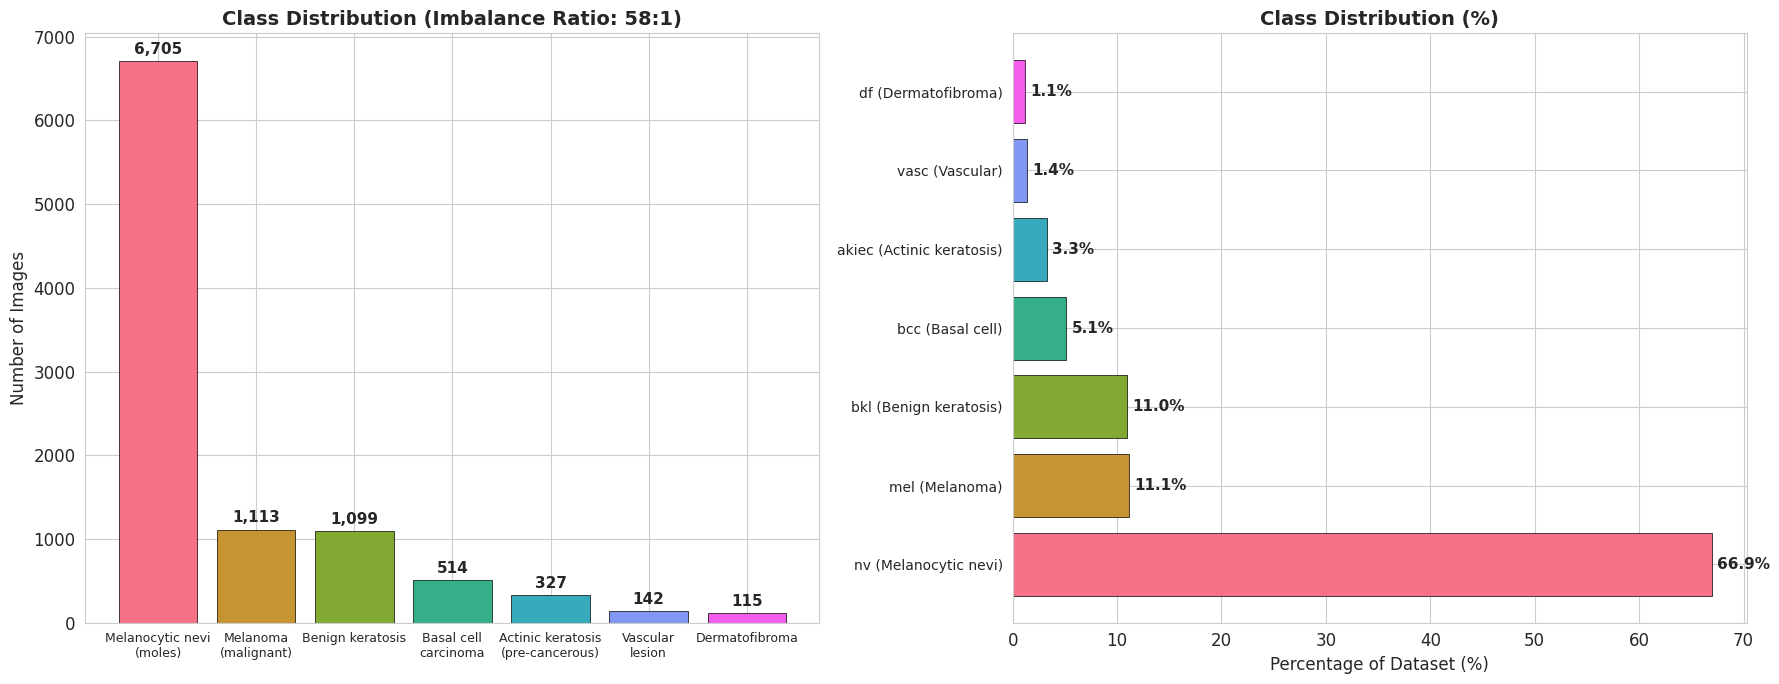


📊 Class Distribution Summary
  nv       6,705 ( 66.9%) ██████████████████████████████████████████████████████████████████
  mel      1,113 ( 11.1%) ███████████
  bkl      1,099 ( 11.0%) ██████████
  bcc        514 (  5.1%) █████
  akiec      327 (  3.3%) ███
  vasc       142 (  1.4%) █
  df         115 (  1.1%) █

  Imbalance ratio: 58:1 (largest / smallest class)
  ⚠️  This is SEVERE imbalance. We MUST use:
     1. WeightedRandomSampler (oversample rare classes)
     2. Focal Loss (focus on hard/rare examples)
     3. Balanced accuracy as primary metric (NOT regular accuracy)


In [10]:
# ============================================================================
# CELL 7: Class Distribution — Bar Chart
# ============================================================================
# RATIONALE: A bar chart is the clearest way to visualize class counts.
# We sort by count (descending) so the imbalance is immediately visible.
# We add count labels on each bar because exact numbers matter in medical ML.
#
# We also compute the IMBALANCE RATIO (max_class / min_class) which is
# a standard metric in the literature. A ratio > 10 is "severely imbalanced".
# ============================================================================

# Full diagnostic names for readability
DX_FULL_NAMES = {
    'nv': 'Melanocytic nevi\n(moles)',
    'mel': 'Melanoma\n(malignant)',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell\ncarcinoma',
    'akiec': 'Actinic keratosis\n(pre-cancerous)',
    'vasc': 'Vascular\nlesion',
    'df': 'Dermatofibroma',
}

# Compute class counts
class_counts = df['dx'].value_counts()
imbalance_ratio = class_counts.max() / class_counts.min()

# Create figure with two subplots: counts and percentages
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Absolute counts ---
colors = sns.color_palette('husl', n_colors=7)
bars = axes[0].bar(
    range(len(class_counts)),
    class_counts.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)

# Add count labels on bars
for bar, count in zip(bars, class_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f'{count:,}',
        ha='center', va='bottom', fontweight='bold', fontsize=11
    )

axes[0].set_xticks(range(len(class_counts)))
axes[0].set_xticklabels([DX_FULL_NAMES.get(dx, dx) for dx in class_counts.index], fontsize=9)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title(f'Class Distribution (Imbalance Ratio: {imbalance_ratio:.0f}:1)', fontsize=14, fontweight='bold')

# --- Subplot 2: Percentage (shows how severe the imbalance is) ---
class_pct = (class_counts / len(df) * 100)
axes[1].barh(
    range(len(class_pct)),
    class_pct.values,
    color=colors,
    edgecolor='black',
    linewidth=0.5
)
axes[1].set_yticks(range(len(class_pct)))
axes[1].set_yticklabels([f'{dx} ({DX_FULL_NAMES.get(dx, dx).split(chr(10))[0]})' for dx in class_pct.index], fontsize=10)
axes[1].set_xlabel('Percentage of Dataset (%)', fontsize=12)
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

# Add percentage labels
for i, (pct, dx) in enumerate(zip(class_pct.values, class_pct.index)):
    axes[1].text(pct + 0.5, i, f'{pct:.1f}%', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_class_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print(f'\n📊 Class Distribution Summary')
print('=' * 50)
for dx, count in class_counts.items():
    pct = 100 * count / len(df)
    bar = '█' * int(pct)
    print(f'  {dx:8s} {count:5,} ({pct:5.1f}%) {bar}')
print(f'\n  Imbalance ratio: {imbalance_ratio:.0f}:1 (largest / smallest class)')
print(f'  ⚠️  This is SEVERE imbalance. We MUST use:')
print(f'     1. WeightedRandomSampler (oversample rare classes)')
print(f'     2. Focal Loss (focus on hard/rare examples)')
print(f'     3. Balanced accuracy as primary metric (NOT regular accuracy)')

In [11]:
# ============================================================================
# CELL 8: Compute Class Weights for Training
# ============================================================================
# RATIONALE: Class weights are INVERSELY proportional to class frequency.
# A class with 6705 images gets a LOW weight (don't oversample it).
# A class with 115 images gets a HIGH weight (sample it more often).
#
# Formula: weight_i = total_samples / (num_classes × count_i)
# This ensures that each class contributes equally to the loss function.
#
# These weights will be directly used in:
#   1. WeightedRandomSampler (to balance batches)
#   2. Focal Loss (as alpha parameter)
# ============================================================================

total_samples = len(df)
num_classes = df['dx'].nunique()

print('⚖️  Class Weights (for WeightedRandomSampler & Focal Loss)')
print('=' * 60)
print(f'{"Class":10s} {"Count":>8s} {"Weight":>10s} {"Effective Sampling":>20s}')
print('-' * 60)

class_weights = {}
for dx, count in class_counts.items():
    # Standard weight formula from sklearn
    weight = total_samples / (num_classes * count)
    class_weights[dx] = weight
    effective = count * weight
    print(f'{dx:10s} {count:8,} {weight:10.3f} {effective:20.0f}')

print(f'\n💡 Interpretation:')
min_weight_dx = min(class_weights, key=class_weights.get)
max_weight_dx = max(class_weights, key=class_weights.get)
print(f'   {max_weight_dx} has weight {class_weights[max_weight_dx]:.2f} → sampled {class_weights[max_weight_dx]:.0f}x more often')
print(f'   {min_weight_dx} has weight {class_weights[min_weight_dx]:.2f} → sampled at normal rate')
print(f'\n   After weighting, each class contributes ~equally to each training batch.')

⚖️  Class Weights (for WeightedRandomSampler & Focal Loss)
Class         Count     Weight   Effective Sampling
------------------------------------------------------------
nv            6,705      0.213                 1431
mel           1,113      1.285                 1431
bkl           1,099      1.302                 1431
bcc             514      2.783                 1431
akiec           327      4.375                 1431
vasc            142     10.075                 1431
df              115     12.441                 1431

💡 Interpretation:
   df has weight 12.44 → sampled 12x more often
   nv has weight 0.21 → sampled at normal rate

   After weighting, each class contributes ~equally to each training batch.


---
## Section 5: Data Leakage Analysis (CRITICAL!)

### What is Data Leakage?

**Data leakage** is when information from the test/validation set "leaks" into the training set, making your model appear better than it actually is.

In HAM10000, the same **lesion** can have **multiple images** (same mole photographed at different times). If image A and image B are from the same lesion, and A goes to training while B goes to validation:
- The model essentially "memorizes" what this specific mole looks like
- It gets a high validation score, but it's NOT generalizing — it's just recognizing a mole it already saw
- Real-world performance will be MUCH worse

> ⚠️ **This is the #1 mistake in medical imaging research.** Many published papers have inflated results due to leakage.

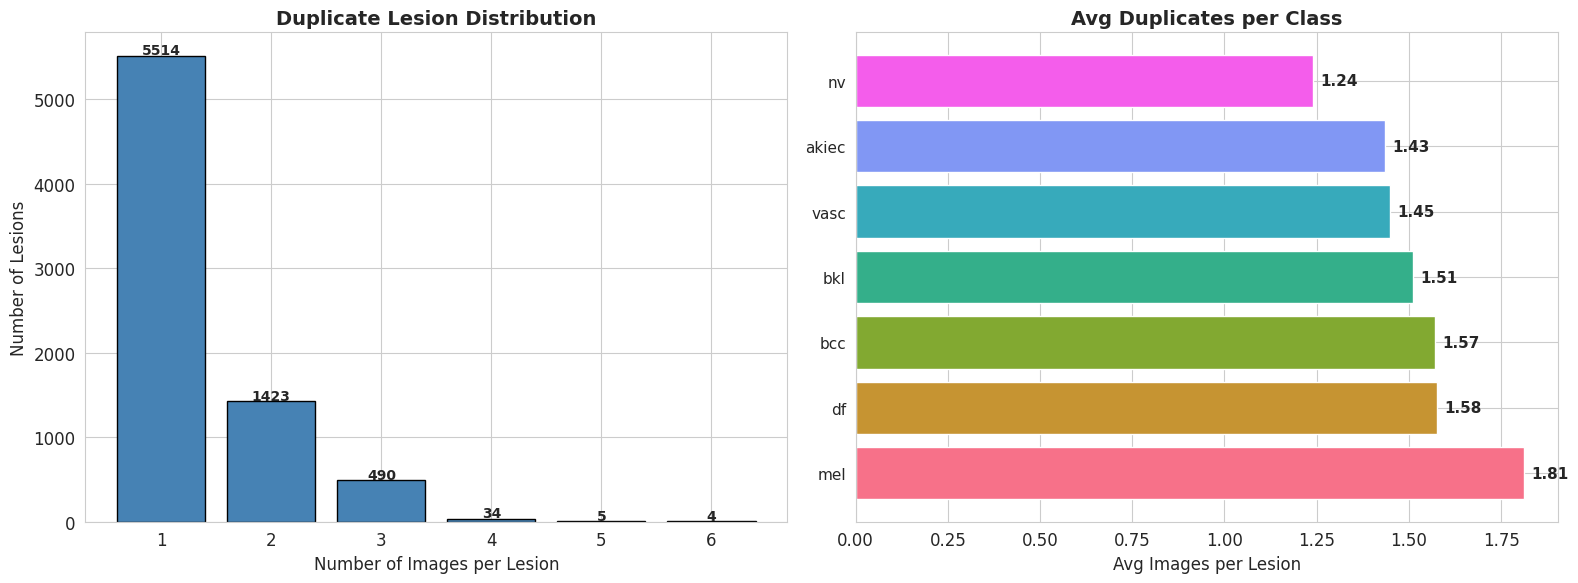


🔍 Duplicate Lesion Summary
  Unique lesions: 7,470
  Lesions with 1 image: 5,514 (73.8%)
  Lesions with >1 image: 1,956 (26.2%)
  Extra images (duplicates): 2,545 (25.4% of all images)

  🚨 CRITICAL TRAINING DECISION:
     We MUST use GroupKFold or split by lesion_id, NOT image_id!
     Our StratifiedKFold must stratify on dx AND group by lesion_id.
     → Use StratifiedGroupKFold from sklearn.


In [12]:
# ============================================================================
# CELL 9: Detect Duplicate Lesions (Data Leakage Risk)
# ============================================================================
# RATIONALE: We MUST split data by LESION_ID, not by IMAGE_ID.
# If we split by image_id, different images of the same mole could end up
# in both training and validation → data leakage → inflated metrics.
#
# This analysis quantifies the risk and will directly influence our
# StratifiedKFold implementation in dataset.py.
# ============================================================================

# Group images by lesion_id
lesion_groups = df.groupby('lesion_id')
images_per_lesion = lesion_groups['image_id'].count()

# Distribution of images per lesion
dup_dist = images_per_lesion.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Subplot 1: How many lesions have N images? ---
axes[0].bar(dup_dist.index, dup_dist.values, color='steelblue', edgecolor='black')
for x, y in zip(dup_dist.index, dup_dist.values):
    axes[0].text(x, y + 20, str(y), ha='center', fontweight='bold', fontsize=10)
axes[0].set_xlabel('Number of Images per Lesion', fontsize=12)
axes[0].set_ylabel('Number of Lesions', fontsize=12)
axes[0].set_title('Duplicate Lesion Distribution', fontsize=14, fontweight='bold')

# --- Subplot 2: Breakdown by class ---
# RATIONALE: Some classes might have MORE duplicates than others.
# e.g., nevi might be monitored over time (follow-up), creating many
# duplicate images per lesion.
dup_by_class = df.groupby('dx').apply(
    lambda g: g.groupby('lesion_id')['image_id'].count().mean()
).sort_values(ascending=False)

axes[1].barh(range(len(dup_by_class)), dup_by_class.values, color=colors[:len(dup_by_class)])
axes[1].set_yticks(range(len(dup_by_class)))
axes[1].set_yticklabels(dup_by_class.index, fontsize=11)
axes[1].set_xlabel('Avg Images per Lesion', fontsize=12)
axes[1].set_title('Avg Duplicates per Class', fontsize=14, fontweight='bold')
for i, v in enumerate(dup_by_class.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_duplicate_lesions.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
single_image = (images_per_lesion == 1).sum()
multi_image = (images_per_lesion > 1).sum()
total_extra = len(df) - len(images_per_lesion)

print(f'\n🔍 Duplicate Lesion Summary')
print('=' * 60)
print(f'  Unique lesions: {len(images_per_lesion):,}')
print(f'  Lesions with 1 image: {single_image:,} ({100*single_image/len(images_per_lesion):.1f}%)')
print(f'  Lesions with >1 image: {multi_image:,} ({100*multi_image/len(images_per_lesion):.1f}%)')
print(f'  Extra images (duplicates): {total_extra:,} ({100*total_extra/len(df):.1f}% of all images)')
print(f'\n  🚨 CRITICAL TRAINING DECISION:')
print(f'     We MUST use GroupKFold or split by lesion_id, NOT image_id!')
print(f'     Our StratifiedKFold must stratify on dx AND group by lesion_id.')
print(f'     → Use StratifiedGroupKFold from sklearn.')

---
## Section 6: Demographic Analysis

Understanding the **patient demographics** helps us:
1. Know if the dataset is representative of the real population
2. Identify potential biases (e.g., mostly old white males → model might struggle with young dark-skinned patients)
3. Some demographics correlate with certain conditions (melanoma is more common in older patients)

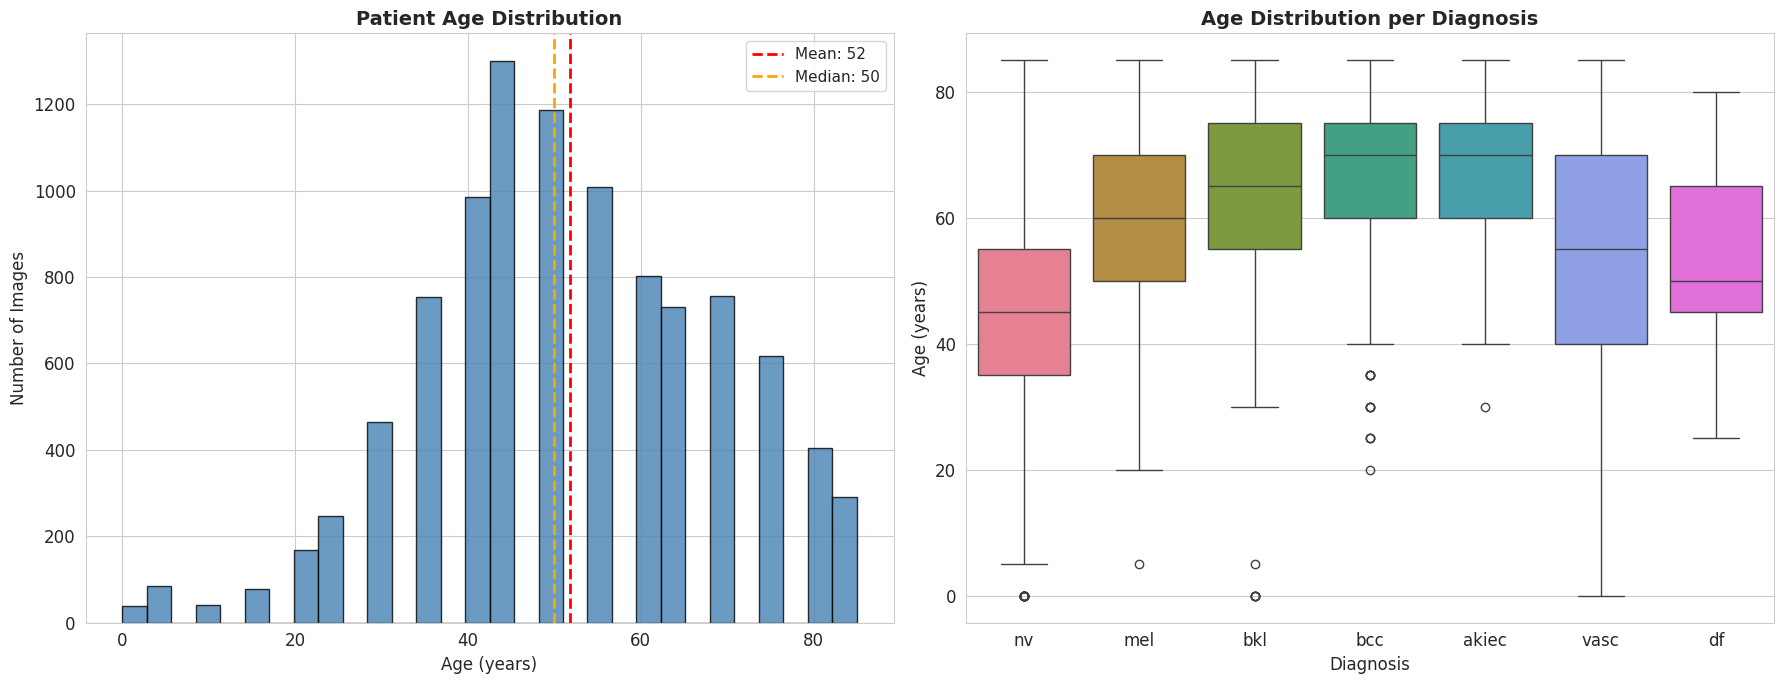


📊 Age Summary:
  Missing ages: 57 (0.6%)
  Mean: 51.9, Median: 50.0
  Range: 0 to 85

💡 Note: We're doing IMAGE classification, not using age as a feature.
   But knowing this helps us understand biases in the dataset.


In [13]:
# ============================================================================
# CELL 10: Age Distribution Analysis
# ============================================================================
# RATIONALE: Age is a strong predictor in dermatology. Melanoma incidence
# increases with age. Understanding the age distribution helps us:
#   1. Know if we have enough samples across all age groups
#   2. Decide if age should be a model feature (multimodal approach)
#   3. Identify potential biases
#
# We plot:
#   - Overall age distribution (histogram)
#   - Age distribution PER CLASS (boxplot) — do some conditions appear at
#     specific ages? This would be clinically meaningful.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Overall age distribution ---
axes[0].hist(df['age'].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.0f}')
axes[0].axvline(df['age'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {df["age"].median():.0f}')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)
axes[0].set_title('Patient Age Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)

# --- Subplot 2: Age per class (boxplot) ---
# RATIONALE: Boxplots show median, quartiles, and outliers — perfect for
# comparing distributions across groups. If melanoma patients are older,
# the model might learn "old → melanoma" as a shortcut (spurious correlation).
order = class_counts.index.tolist()  # Sort by frequency
sns.boxplot(data=df, x='dx', y='age', order=order, ax=axes[1], palette='husl')
axes[1].set_xlabel('Diagnosis', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution per Diagnosis', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_age_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

# Print missing age info
missing_age = df['age'].isna().sum()
print(f'\n📊 Age Summary:')
print(f'  Missing ages: {missing_age} ({100*missing_age/len(df):.1f}%)')
print(f'  Mean: {df["age"].mean():.1f}, Median: {df["age"].median():.1f}')
print(f'  Range: {df["age"].min():.0f} to {df["age"].max():.0f}')
print(f'\n💡 Note: We\'re doing IMAGE classification, not using age as a feature.')
print(f'   But knowing this helps us understand biases in the dataset.')

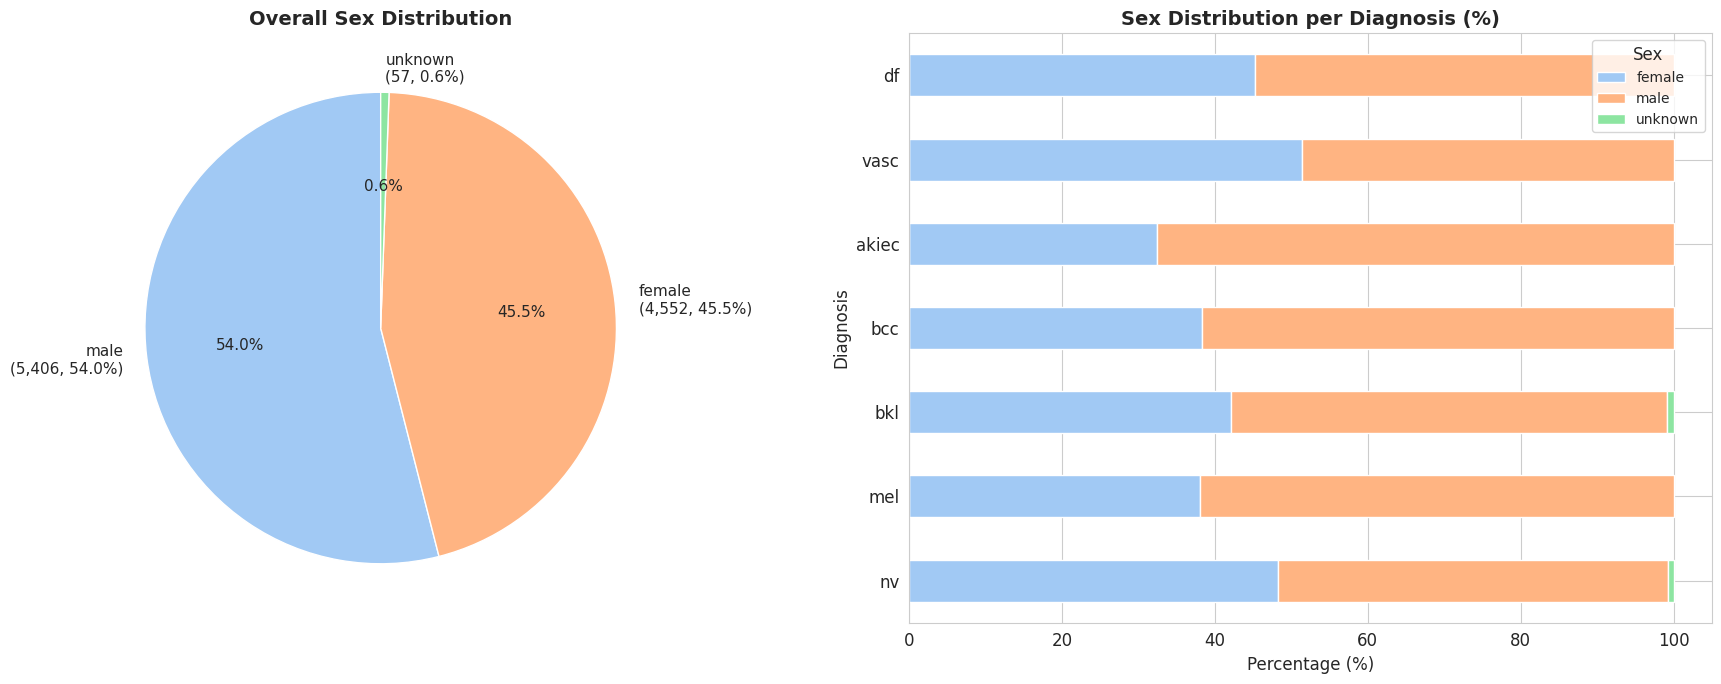


 Sex Summary:
  male: 5,406 (54.0%)
  female: 4,552 (45.5%)
  unknown: 57 (0.6%)


In [28]:
# ============================================================================
# CELL 11: Sex Distribution Analysis
# ============================================================================
# RATIONALE: Understanding sex distribution per class helps us identify:
#   1. Dataset bias (is one sex over-represented?)
#   2. Clinical patterns (some conditions are more common in one sex)
#
# We use a stacked bar chart because it shows BOTH the total count per class
# AND the sex breakdown within each class.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Overall sex distribution ---
sex_counts = df['sex'].value_counts(dropna=False)
axes[0].pie(
    sex_counts.values,
    labels=[f'{k}\n({v:,}, {100*v/len(df):.1f}%)' for k, v in sex_counts.items()],
    colors=sns.color_palette('pastel')[:len(sex_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11}
)
axes[0].set_title('Overall Sex Distribution', fontsize=14, fontweight='bold')

# --- Subplot 2: Sex distribution per class ---
sex_by_class = pd.crosstab(df['dx'], df['sex'], normalize='index') * 100
sex_by_class = sex_by_class.loc[class_counts.index]  # Sort by frequency
sex_by_class.plot(kind='barh', stacked=True, ax=axes[1], color=sns.color_palette('pastel')[:3])
axes[1].set_xlabel('Percentage (%)', fontsize=12)
axes[1].set_ylabel('Diagnosis', fontsize=12)
axes[1].set_title('Sex Distribution per Diagnosis (%)', fontsize=14, fontweight='bold')
axes[1].legend(title='Sex', fontsize=10)

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_sex_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Sex Summary:')
for sex, count in sex_counts.items():
    print(f'  {sex}: {count:,} ({100*count/len(df):.1f}%)')

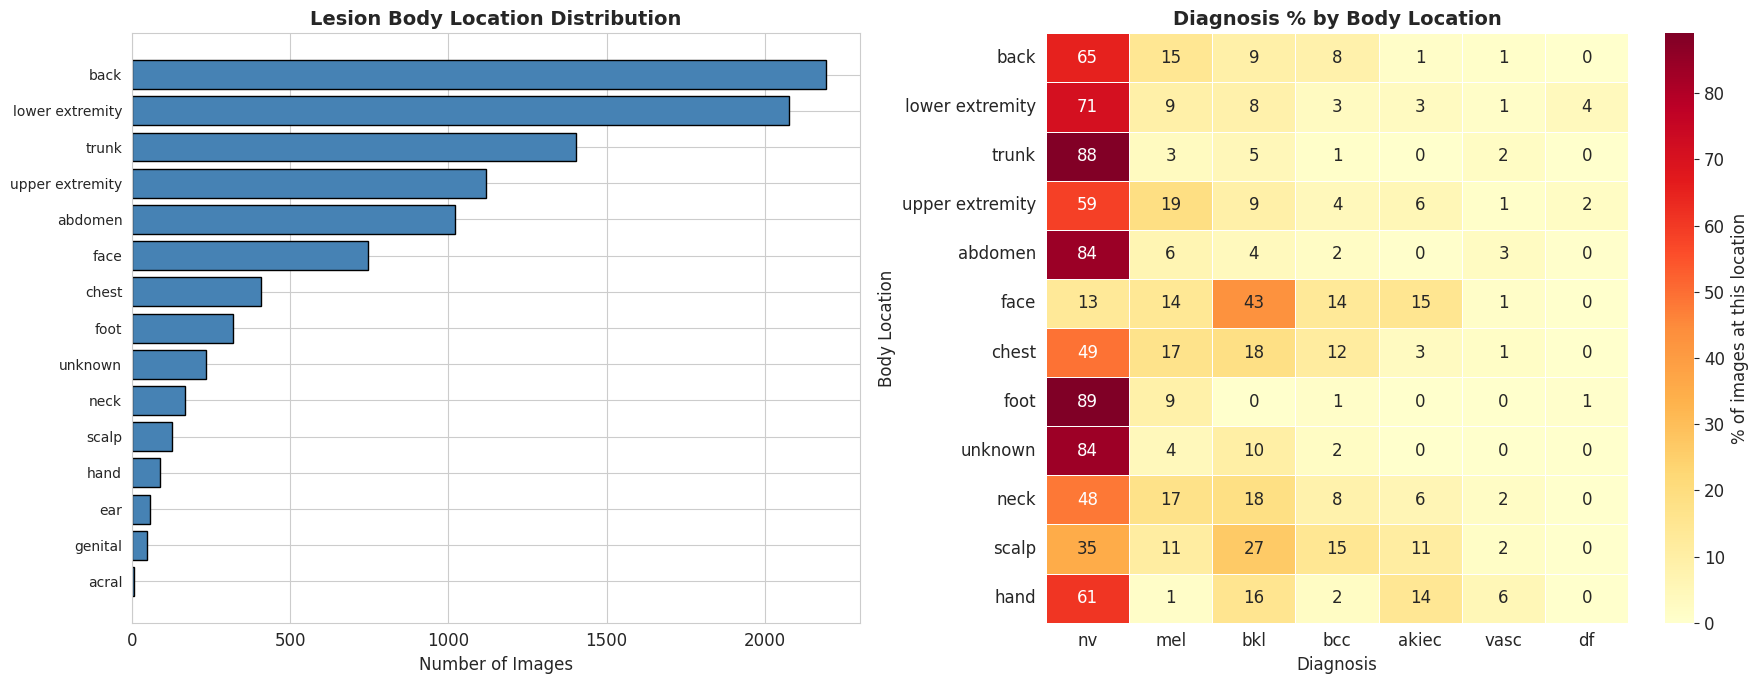


📊 Localization Summary:
  Most common location: back (2,192 images)
  Unique locations: 15
  Unknown/missing: 234


In [15]:
# ============================================================================
# CELL 12: Body Localization Analysis
# ============================================================================
# RATIONALE: The body location where the lesion was found is important because:
#   1. Certain lesions appear more often in specific body parts
#   2. Skin texture/color varies by location (hairy back vs smooth face)
#   3. This could become a confounding variable — if melanoma mostly appears
#      on the trunk and we have background skin in images, the model might
#      learn to detect "trunk skin" instead of actual melanoma features.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Overall localization distribution ---
loc_counts = df['localization'].value_counts()
axes[0].barh(range(len(loc_counts)), loc_counts.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(loc_counts)))
axes[0].set_yticklabels(loc_counts.index, fontsize=10)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Lesion Body Location Distribution', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# --- Subplot 2: Heatmap of localization × diagnosis ---
# RATIONALE: A heatmap reveals correlations between location and diagnosis.
# If melanoma is clustered in specific locations, this is clinically meaningful.
loc_dx_cross = pd.crosstab(df['localization'], df['dx'], normalize='index') * 100
loc_dx_cross = loc_dx_cross.loc[loc_counts.index[:12]]  # Top 12 locations
loc_dx_cross = loc_dx_cross[class_counts.index]  # Sort columns by frequency

sns.heatmap(
    loc_dx_cross,
    annot=True, fmt='.0f', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5,
    cbar_kws={'label': '% of images at this location'}
)
axes[1].set_title('Diagnosis % by Body Location', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Diagnosis', fontsize=12)
axes[1].set_ylabel('Body Location', fontsize=12)

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_localization.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Localization Summary:')
print(f'  Most common location: {loc_counts.index[0]} ({loc_counts.values[0]:,} images)')
print(f'  Unique locations: {df["localization"].nunique()}')
missing_loc = df['localization'].isna().sum() + (df['localization'] == 'unknown').sum()
print(f'  Unknown/missing: {missing_loc}')

---
## Section 7: Diagnosis Confirmation Method Analysis

The **dx_type** column tells us HOW each diagnosis was confirmed. This is crucial for understanding **label quality**:

| Method | Reliability | Description |
|---|---|---|
| `histo` | ⭐⭐⭐⭐⭐ | Histopathology — biopsy examined under microscope. Gold standard. |
| `confocal` | ⭐⭐⭐⭐ | Confocal microscopy — non-invasive but highly accurate |
| `follow_up` | ⭐⭐⭐ | Serial imaging over time — confirmed by lack of change |
| `consensus` | ⭐⭐⭐ | Expert panel agreement — subjective but reasonable |

> 💡 **Why this matters**: If most labels come from `consensus` (expert opinion), some labels could be wrong. The model is only as good as its labels!

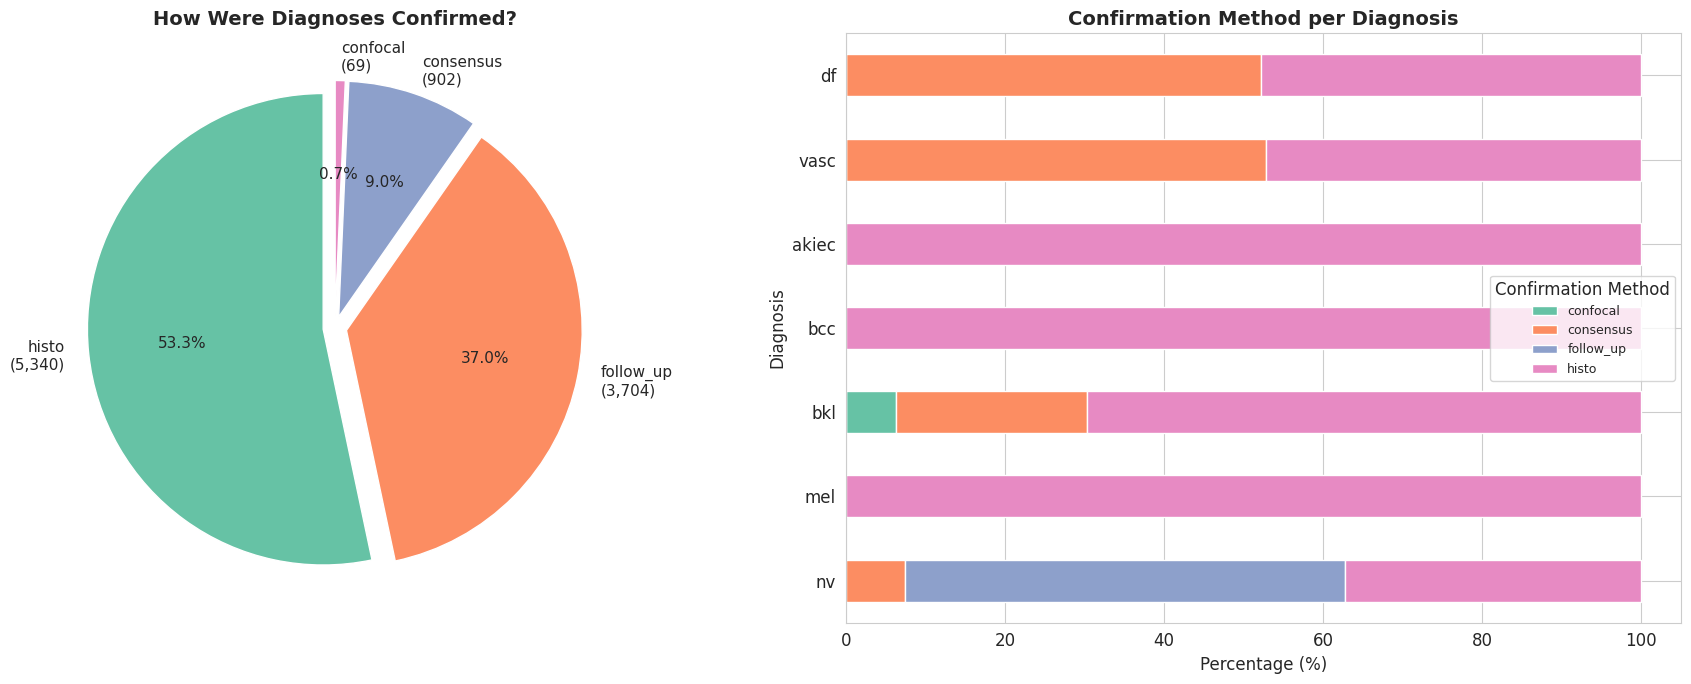


📊 Diagnosis Confirmation Summary:
  nv      :  37.3% histopathology-confirmed (n=6705)
  mel     : 100.0% histopathology-confirmed (n=1113)
  bkl     :  69.7% histopathology-confirmed (n=1099)
  bcc     : 100.0% histopathology-confirmed (n=514)
  akiec   : 100.0% histopathology-confirmed (n=327)
  vasc    :  47.2% histopathology-confirmed (n=142)
  df      :  47.8% histopathology-confirmed (n=115)

  Overall histopathology rate: 53.3%

💡 Insight: Higher histo % = more reliable labels.
   Consider label_smoothing=0.1 in training to account for label noise.


In [16]:
# ============================================================================
# CELL 13: Diagnosis Confirmation Method Analysis
# ============================================================================
# RATIONALE: Label quality directly affects model quality. If most melanoma
# labels are histopathology-confirmed, we have high confidence. If they're
# "consensus" (expert agreement), some could be misdiagnosed.
#
# This analysis helps us decide:
#   1. Should we use label smoothing? (If labels might be noisy → YES)
#   2. Should we weight histopathology-confirmed samples higher?
#   3. How much to trust our evaluation metrics
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Overall dx_type distribution ---
dx_type_counts = df['dx_type'].value_counts()
axes[0].pie(
    dx_type_counts.values,
    labels=[f'{k}\n({v:,})' for k, v in dx_type_counts.items()],
    colors=sns.color_palette('Set2')[:len(dx_type_counts)],
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 11},
    explode=[0.05] * len(dx_type_counts)
)
axes[0].set_title('How Were Diagnoses Confirmed?', fontsize=14, fontweight='bold')

# --- Subplot 2: dx_type breakdown per class ---
dx_type_by_class = pd.crosstab(df['dx'], df['dx_type'], normalize='index') * 100
dx_type_by_class = dx_type_by_class.loc[class_counts.index]
dx_type_by_class.plot(
    kind='barh', stacked=True, ax=axes[1],
    color=sns.color_palette('Set2')[:len(dx_type_counts)]
)
axes[1].set_xlabel('Percentage (%)', fontsize=12)
axes[1].set_ylabel('Diagnosis', fontsize=12)
axes[1].set_title('Confirmation Method per Diagnosis', fontsize=14, fontweight='bold')
axes[1].legend(title='Confirmation Method', fontsize=9)

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_dx_type.png'), dpi=150, bbox_inches='tight')
plt.show()

# Detailed breakdown
print(f'\n Diagnosis Confirmation Summary:')
print('=' * 60)
for dx in class_counts.index:
    subset = df[df['dx'] == dx]
    histo_pct = 100 * (subset['dx_type'] == 'histo').sum() / len(subset)
    print(f'  {dx:8s}: {histo_pct:5.1f}% histopathology-confirmed (n={len(subset)})')

total_histo = (df['dx_type'] == 'histo').sum()
print(f'\n  Overall histopathology rate: {100*total_histo/len(df):.1f}%')
print(f'\n💡 Insight: Higher histo % = more reliable labels.')
print(f'   Consider label_smoothing=0.1 in training to account for label noise.')

---
## Section 8: Image Quality Analysis

Now we analyze the actual **images themselves**. This is critical for:
1. **Resize strategy** — What sizes are the originals? Do we lose too much by resizing to 224×224?
2. **Aspect ratio** — Are images square or rectangular? Squishing could distort features.
3. **Quality issues** — Dark images, blurry images, artifacts?
4. **Color distribution** — Do different classes have different color profiles?

🔍 Analyzing image dimensions (this reads only headers, not full images)...

📐 Image Dimensions Summary (10,015 images analyzed):
  Width:  min=600, max=600, mean=600
  Height: min=450, max=450, mean=450
  Aspect ratio: min=1.33, max=1.33, mean=1.33
  File size: min=83KB, max=479KB, mean=270KB
  Unique (width, height) combinations: 1
    600×450: 10,015 images


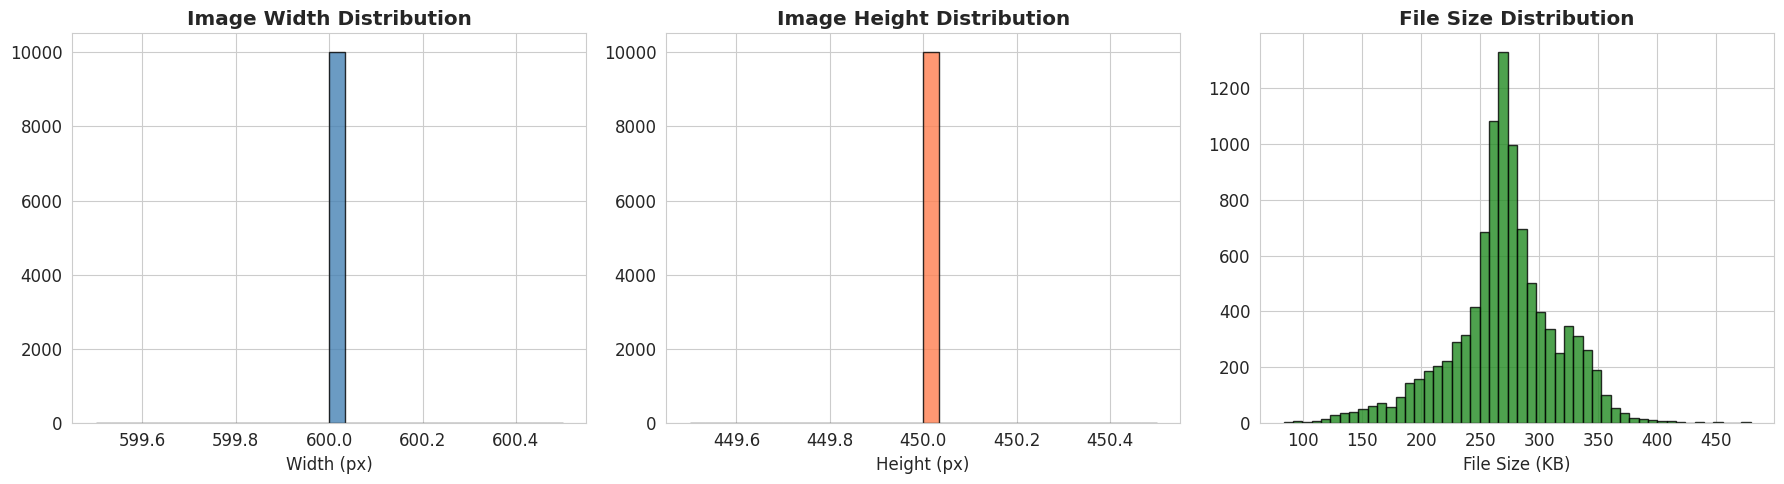


💡 Resize Strategy Recommendation:
   Original images are ~600×450
   DINOv2 expects 224×224 input
   → Resize to 256 (short edge) then CenterCrop to 224 preserves aspect ratio
   → For training: RandomResizedCrop(224) adds augmentation
   → Total disk space: 2642 MB


In [17]:
# ============================================================================
# CELL 14: Image Dimensions Analysis
# ============================================================================
# RATIONALE: Before resizing images to 224×224 for the model, we need to
# know the original dimensions. This tells us:
#   1. How much information we lose by downscaling
#   2. Whether aspect ratios vary (they do — some are 600×450, others 1024×767)
#   3. Whether to use Resize(224) + CenterCrop or Resize(256) + RandomCrop
#
# We sample a subset (not all 10K) because reading image dimensions is
# fast but we don't need exhaustive coverage for this check.
# ============================================================================

# Sample images for dimension analysis (all images — it's fast with PIL lazy loading)
print('🔍 Analyzing image dimensions (this reads only headers, not full images)...')

widths = []
heights = []
aspect_ratios = []
file_sizes_kb = []

for img_path in all_train_images:
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)
            aspect_ratios.append(w / h)
        file_sizes_kb.append(os.path.getsize(img_path) / 1024)
    except Exception as e:
        print(f'  ⚠️ Error reading {img_path.name}: {e}')

print(f'\n📐 Image Dimensions Summary ({len(widths):,} images analyzed):')
print('=' * 60)
print(f'  Width:  min={min(widths)}, max={max(widths)}, mean={np.mean(widths):.0f}')
print(f'  Height: min={min(heights)}, max={max(heights)}, mean={np.mean(heights):.0f}')
print(f'  Aspect ratio: min={min(aspect_ratios):.2f}, max={max(aspect_ratios):.2f}, mean={np.mean(aspect_ratios):.2f}')
print(f'  File size: min={min(file_sizes_kb):.0f}KB, max={max(file_sizes_kb):.0f}KB, mean={np.mean(file_sizes_kb):.0f}KB')

# Check if all images are the same size
unique_sizes = set(zip(widths, heights))
print(f'  Unique (width, height) combinations: {len(unique_sizes)}')
if len(unique_sizes) <= 5:
    for w, h in sorted(unique_sizes):
        count = sum(1 for ww, hh in zip(widths, heights) if ww == w and hh == h)
        print(f'    {w}×{h}: {count:,} images')

# Plot dimensions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(widths, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Width (px)')
axes[0].set_title('Image Width Distribution', fontweight='bold')

axes[1].hist(heights, bins=30, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Height (px)')
axes[1].set_title('Image Height Distribution', fontweight='bold')

axes[2].hist(file_sizes_kb, bins=50, color='forestgreen', edgecolor='black', alpha=0.8)
axes[2].set_xlabel('File Size (KB)')
axes[2].set_title('File Size Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_image_dimensions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n💡 Resize Strategy Recommendation:')
print(f'   Original images are ~{np.mean(widths):.0f}×{np.mean(heights):.0f}')
print(f'   DINOv2 expects 224×224 input')
print(f'   → Resize to 256 (short edge) then CenterCrop to 224 preserves aspect ratio')
print(f'   → For training: RandomResizedCrop(224) adds augmentation')
print(f'   → Total disk space: {sum(file_sizes_kb)/1024:.0f} MB')

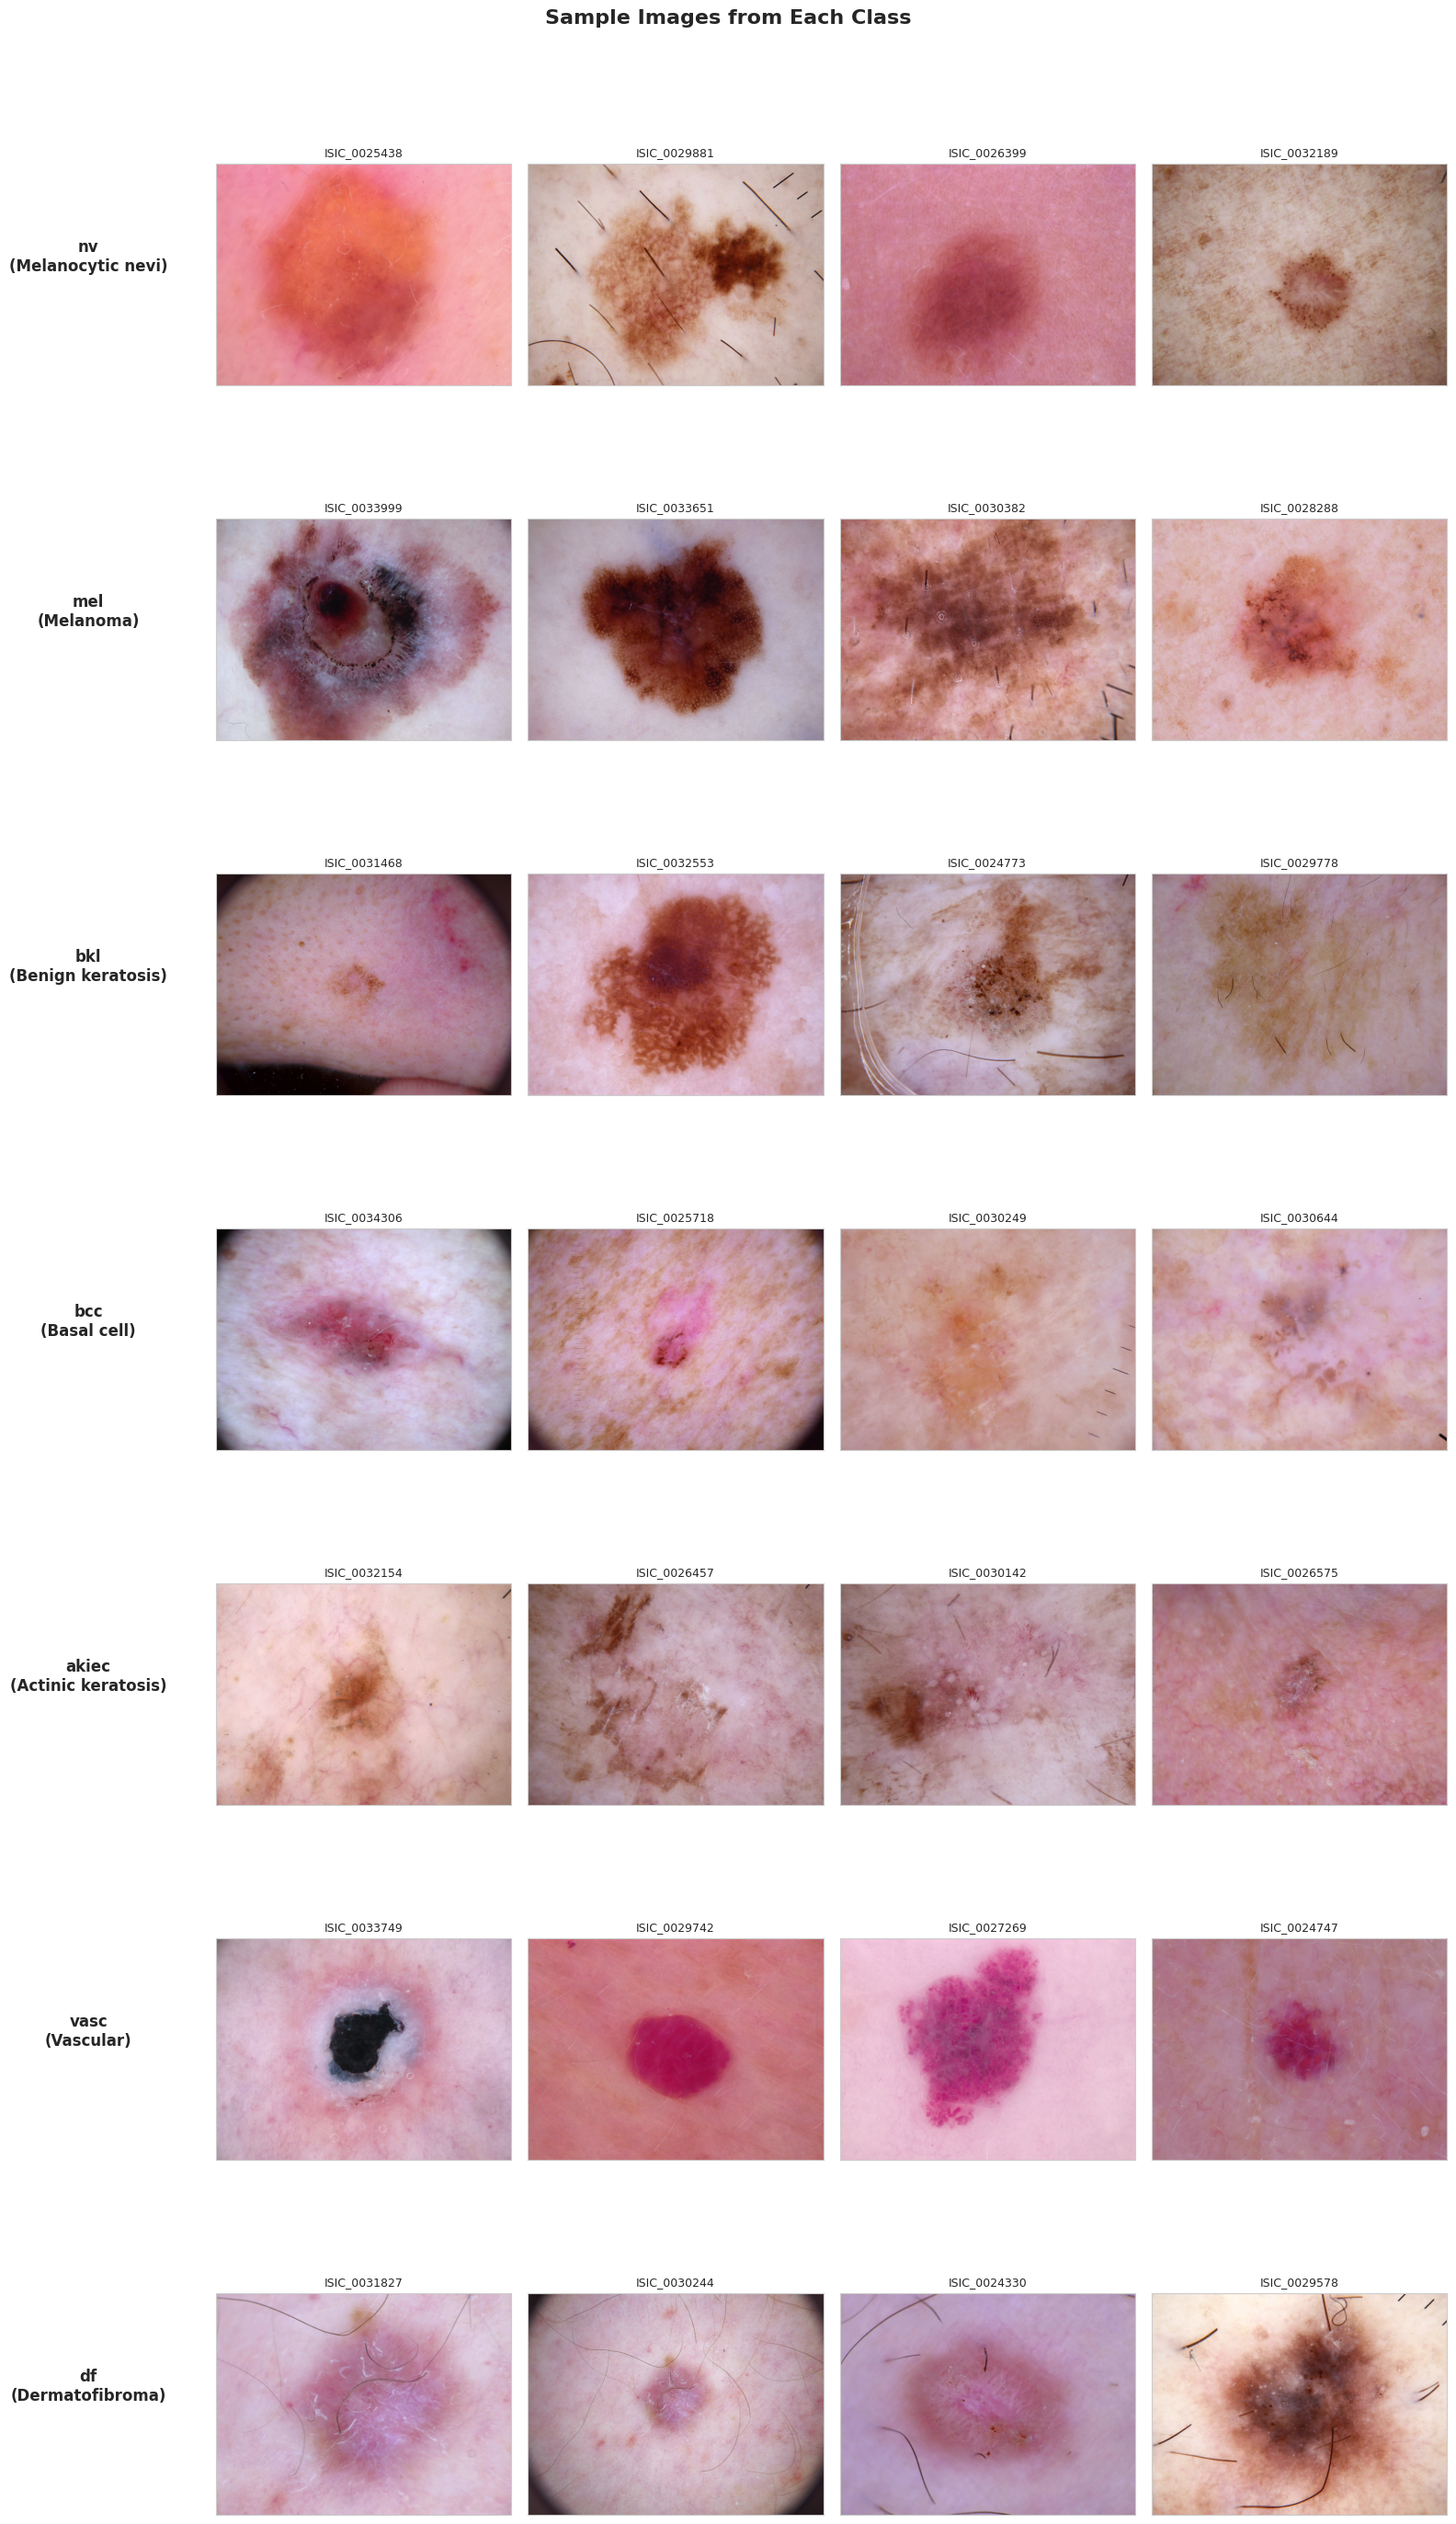


💡 Visual Inspection Notes:
  - Look for: Are lesions centered? Any non-skin artifacts?
  - nv (nevi/moles): Small, dark, round — easy cases for the model
  - mel (melanoma): Irregular borders, multiple colors — hardest class
  - bkl (keratosis): Scaly, textured surface
  - bcc: Pearly, translucent edges
  - Flipping/rotating these doesn't change diagnosis → augmentation is valid!


In [18]:
# ============================================================================
# CELL 15: Sample Image Grid — Visualize Each Class
# ============================================================================
# RATIONALE: You should ALWAYS visually inspect samples from each class.
# This is the most important sanity check because:
#   1. You see what the model will see — are the lesions centered? Cropped well?
#   2. You notice quality issues — blur, artifacts, non-skin images
#   3. You build intuition — can YOU tell the classes apart? If humans can't,
#      the model will struggle too.
#   4. You understand WHY augmentation helps — rotate, flip, color jitter
#      all make sense once you see the actual images.
# ============================================================================

# Show 4 random samples per class
n_samples = 4
classes_sorted = class_counts.index.tolist()
n_classes = len(classes_sorted)

fig, axes = plt.subplots(n_classes, n_samples, figsize=(4 * n_samples, 4 * n_classes))

np.random.seed(42)  # Reproducible random samples

for row, dx in enumerate(classes_sorted):
    # Get all image_ids for this class
    class_image_ids = df[df['dx'] == dx]['image_id'].tolist()
    # Sample N random ones
    sampled_ids = np.random.choice(class_image_ids, size=min(n_samples, len(class_image_ids)), replace=False)
    
    for col, img_id in enumerate(sampled_ids):
        if img_id in image_path_map:
            img = Image.open(image_path_map[img_id])
            axes[row, col].imshow(img)
            if col == 0:
                axes[row, col].set_ylabel(
                    f'{dx}\n({DX_FULL_NAMES.get(dx, dx).split(chr(10))[0]})',
                    fontsize=12, fontweight='bold', rotation=0, labelpad=100
                )
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
        axes[row, col].set_title(img_id, fontsize=9)

fig.suptitle('Sample Images from Each Class', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_sample_images.png'), dpi=100, bbox_inches='tight')
plt.show()

print('\n💡 Visual Inspection Notes:')
print('  - Look for: Are lesions centered? Any non-skin artifacts?')
print('  - nv (nevi/moles): Small, dark, round — easy cases for the model')
print('  - mel (melanoma): Irregular borders, multiple colors — hardest class')
print('  - bkl (keratosis): Scaly, textured surface')
print('  - bcc: Pearly, translucent edges')
print('  - Flipping/rotating these doesn\'t change diagnosis → augmentation is valid!')

🎨 Computing channel statistics (sampling 500 images)...


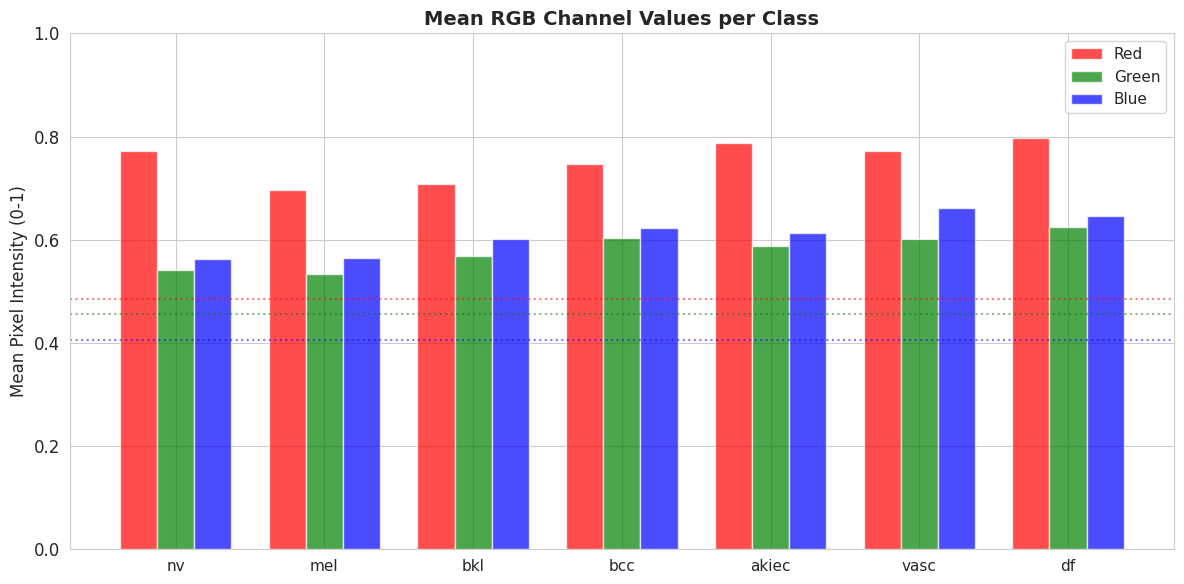


🎨 Dataset Channel Statistics (computed on 500 samples):
  Mean R: 0.7542  (ImageNet: 0.485)
  Mean G: 0.5509  (ImageNet: 0.456)
  Mean B: 0.5763  (ImageNet: 0.406)
  Std  R: 0.0983   (ImageNet: 0.229)
  Std  G: 0.0841   (ImageNet: 0.224)
  Std  B: 0.0931   (ImageNet: 0.225)

💡 Decision: Use ImageNet normalization (not dataset-specific).
   Reason: DINOv2 was pretrained with ImageNet stats. Using different
   stats would put our data in a different distribution than what DINOv2
   expects, degrading pretrained feature quality.


In [19]:
# ============================================================================
# CELL 16: Image Channel Statistics (Mean RGB per Class)
# ============================================================================
# RATIONALE: Computing the mean RGB values tells us:
#   1. Whether classes have different color profiles (useful diagnostic info)
#   2. The dataset-specific mean/std for normalization
#   3. Whether to use ImageNet normalization or dataset-specific normalization
#
# We compare with ImageNet stats because DINOv2 was trained on ImageNet.
# If our data is very different from ImageNet, the pretrained features
# might be less effective.
#
# We sample a subset for speed — computing stats on all 10K images would
# take too long and sampling gives a good enough estimate.
# ============================================================================

print('🎨 Computing channel statistics (sampling 500 images)...')

n_sample = 500
np.random.seed(42)
sample_indices = np.random.choice(len(df), size=min(n_sample, len(df)), replace=False)

# Per-class channel means
class_channel_means = {dx: {'R': [], 'G': [], 'B': []} for dx in classes_sorted}

all_R, all_G, all_B = [], [], []

for idx in sample_indices:
    row = df.iloc[idx]
    img_id = row['image_id']
    dx = row['dx']
    
    if img_id not in image_path_map:
        continue
    
    img = np.array(Image.open(image_path_map[img_id]).resize((224, 224))) / 255.0
    
    r_mean, g_mean, b_mean = img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()
    
    class_channel_means[dx]['R'].append(r_mean)
    class_channel_means[dx]['G'].append(g_mean)
    class_channel_means[dx]['B'].append(b_mean)
    
    all_R.append(r_mean)
    all_G.append(g_mean)
    all_B.append(b_mean)

# Plot channel means per class
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(classes_sorted))
width = 0.25

r_means = [np.mean(class_channel_means[dx]['R']) for dx in classes_sorted]
g_means = [np.mean(class_channel_means[dx]['G']) for dx in classes_sorted]
b_means = [np.mean(class_channel_means[dx]['B']) for dx in classes_sorted]

ax.bar(x - width, r_means, width, label='Red', color='red', alpha=0.7)
ax.bar(x, g_means, width, label='Green', color='green', alpha=0.7)
ax.bar(x + width, b_means, width, label='Blue', color='blue', alpha=0.7)

ax.set_xticks(x)
ax.set_xticklabels(classes_sorted, fontsize=11)
ax.set_ylabel('Mean Pixel Intensity (0-1)', fontsize=12)
ax.set_title('Mean RGB Channel Values per Class', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 1)

# Add ImageNet reference line
ax.axhline(y=0.485, color='red', linestyle=':', alpha=0.5, label='ImageNet R mean')
ax.axhline(y=0.456, color='green', linestyle=':', alpha=0.5, label='ImageNet G mean')
ax.axhline(y=0.406, color='blue', linestyle=':', alpha=0.5, label='ImageNet B mean')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_channel_stats.png'), dpi=150, bbox_inches='tight')
plt.show()

# Dataset-wide stats
print(f'\n🎨 Dataset Channel Statistics (computed on {len(all_R)} samples):')
print(f'  Mean R: {np.mean(all_R):.4f}  (ImageNet: 0.485)')
print(f'  Mean G: {np.mean(all_G):.4f}  (ImageNet: 0.456)')
print(f'  Mean B: {np.mean(all_B):.4f}  (ImageNet: 0.406)')
print(f'  Std  R: {np.std(all_R):.4f}   (ImageNet: 0.229)')
print(f'  Std  G: {np.std(all_G):.4f}   (ImageNet: 0.224)')
print(f'  Std  B: {np.std(all_B):.4f}   (ImageNet: 0.225)')
print(f'\n💡 Decision: Use ImageNet normalization (not dataset-specific).')
print(f'   Reason: DINOv2 was pretrained with ImageNet stats. Using different')
print(f'   stats would put our data in a different distribution than what DINOv2')
print(f'   expects, degrading pretrained feature quality.')

---
## Section 9: Segmentation Mask Analysis

We also have **segmentation masks** — binary images showing WHERE the lesion is in each image. While we're doing **classification** (not segmentation), masks are useful for:
1. Understanding lesion size distribution
2. Sanity-checking Grad-CAM later (is the model looking at the lesion or the background?)
3. Potentially using masks as attention signals during training

🎭 Analyzing segmentation masks (sampling 300)...


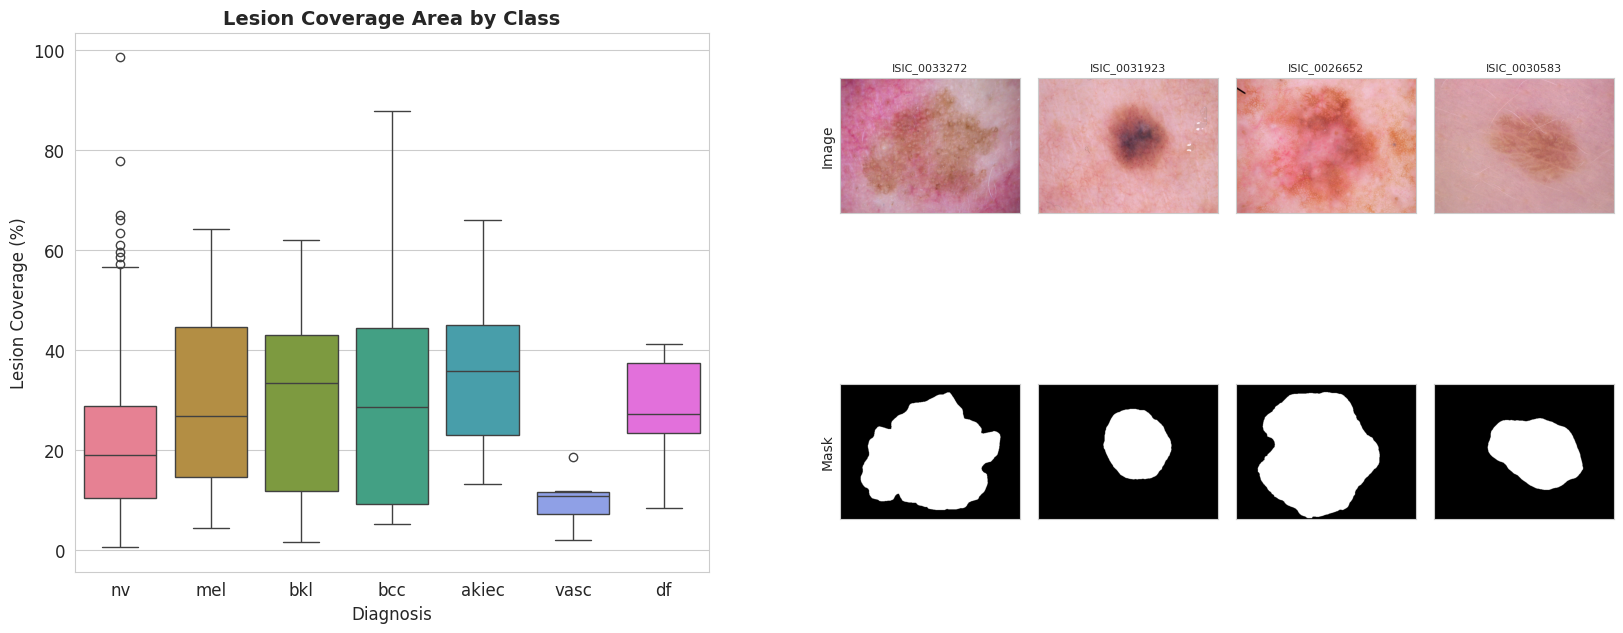


🎭 Segmentation Mask Summary:
  Mean lesion coverage: 24.6%
  Median lesion coverage: 20.0%
  Range: 0.5% to 98.6%

💡 Insight: Lesions cover ~25% of the image on average.
   This means ~75% is background/surrounding skin.
   Grad-CAM should ideally focus on the lesion area, not the background.


In [20]:
# ============================================================================
# CELL 17: Segmentation Mask Analysis
# ============================================================================
# RATIONALE: Segmentation masks tell us the lesion's coverage in the image.
# This is useful because:
#   1. If lesions are tiny, the model needs to focus on small regions
#   2. Large lesions are easier to classify (more pixels of diagnostic info)
#   3. We can compute lesion-to-image ratio per class
#   4. Later, we can compare Grad-CAM heatmaps with ground truth masks
#      to see if the model is looking at the right area.
# ============================================================================

print('🎭 Analyzing segmentation masks (sampling 300)...')

n_mask_samples = 300
np.random.seed(42)

mask_coverage = {dx: [] for dx in classes_sorted}

sample_rows = df.sample(n=min(n_mask_samples, len(df)), random_state=42)

for _, row in sample_rows.iterrows():
    mask_path = SEGMENTATION_DIR / f"{row['image_id']}_segmentation.png"
    if mask_path.exists():
        mask = np.array(Image.open(mask_path).convert('L'))  # Convert to grayscale
        # Coverage = fraction of pixels that are lesion (white = 255)
        coverage = (mask > 128).sum() / mask.size
        mask_coverage[row['dx']].append(coverage)

# Plot lesion coverage per class
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Boxplot of lesion coverage ---
coverage_data = []
for dx in classes_sorted:
    for cov in mask_coverage[dx]:
        coverage_data.append({'dx': dx, 'coverage': cov * 100})
coverage_df = pd.DataFrame(coverage_data)

if len(coverage_df) > 0:
    sns.boxplot(data=coverage_df, x='dx', y='coverage', order=classes_sorted, ax=axes[0], palette='husl')
    axes[0].set_xlabel('Diagnosis', fontsize=12)
    axes[0].set_ylabel('Lesion Coverage (%)', fontsize=12)
    axes[0].set_title('Lesion Coverage Area by Class', fontsize=14, fontweight='bold')

# --- Subplot 2: Sample masks overlaid on images ---
sample_ids_for_viz = df.sample(4, random_state=42)['image_id'].tolist()
for i, img_id in enumerate(sample_ids_for_viz):
    if i >= 4:
        break
    # We use a single axes for a grid
    ax = axes[1] if i == 0 else axes[1]

# Instead, create a grid in subplot 2's space
axes[1].set_visible(False)
gs = fig.add_gridspec(2, 4, left=0.55, right=0.98, bottom=0.1, top=0.9, wspace=0.1, hspace=0.2)

for i, img_id in enumerate(sample_ids_for_viz[:4]):
    if img_id not in image_path_map:
        continue
    ax_img = fig.add_subplot(gs[0, i])
    ax_mask = fig.add_subplot(gs[1, i])
    
    img = Image.open(image_path_map[img_id])
    ax_img.imshow(img)
    ax_img.set_title(img_id, fontsize=8)
    ax_img.set_xticks([])
    ax_img.set_yticks([])
    
    mask_path = SEGMENTATION_DIR / f"{img_id}_segmentation.png"
    if mask_path.exists():
        mask = Image.open(mask_path)
        ax_mask.imshow(mask, cmap='gray')
    ax_mask.set_xticks([])
    ax_mask.set_yticks([])
    if i == 0:
        ax_img.set_ylabel('Image', fontsize=10)
        ax_mask.set_ylabel('Mask', fontsize=10)

plt.savefig(str(DATA_DIR.parent / 'eda_segmentation.png'), dpi=150, bbox_inches='tight')
plt.show()

# Summary
all_coverages = [cov for covers in mask_coverage.values() for cov in covers]
if all_coverages:
    print(f'\n🎭 Segmentation Mask Summary:')
    print(f'  Mean lesion coverage: {np.mean(all_coverages)*100:.1f}%')
    print(f'  Median lesion coverage: {np.median(all_coverages)*100:.1f}%')
    print(f'  Range: {np.min(all_coverages)*100:.1f}% to {np.max(all_coverages)*100:.1f}%')
    print(f'\n💡 Insight: Lesions cover ~{np.mean(all_coverages)*100:.0f}% of the image on average.')
    print(f'   This means ~{100-np.mean(all_coverages)*100:.0f}% is background/surrounding skin.')
    print(f'   Grad-CAM should ideally focus on the lesion area, not the background.')

---
## Section 10: Test Set Analysis

The ISIC 2018 challenge also provides a **held-out test set** with ground truth labels. Let's analyze it to understand:
1. Is it a similar distribution to the training set?
2. Can we use it as our final evaluation benchmark?
3. Are there any distributional shifts between train and test?

📋 Test Set Overview:
  Total test images: 1,512
  Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset']

  First 3 rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset
0,HAMTEST_0000000,ISIC_0034524,nv,follow_up,40.0,female,back,vidir_molemax
1,HAMTEST_0000001,ISIC_0034525,nv,histo,70.0,male,abdomen,rosendahl
2,HAMTEST_0000002,ISIC_0034526,bkl,histo,70.0,male,back,rosendahl


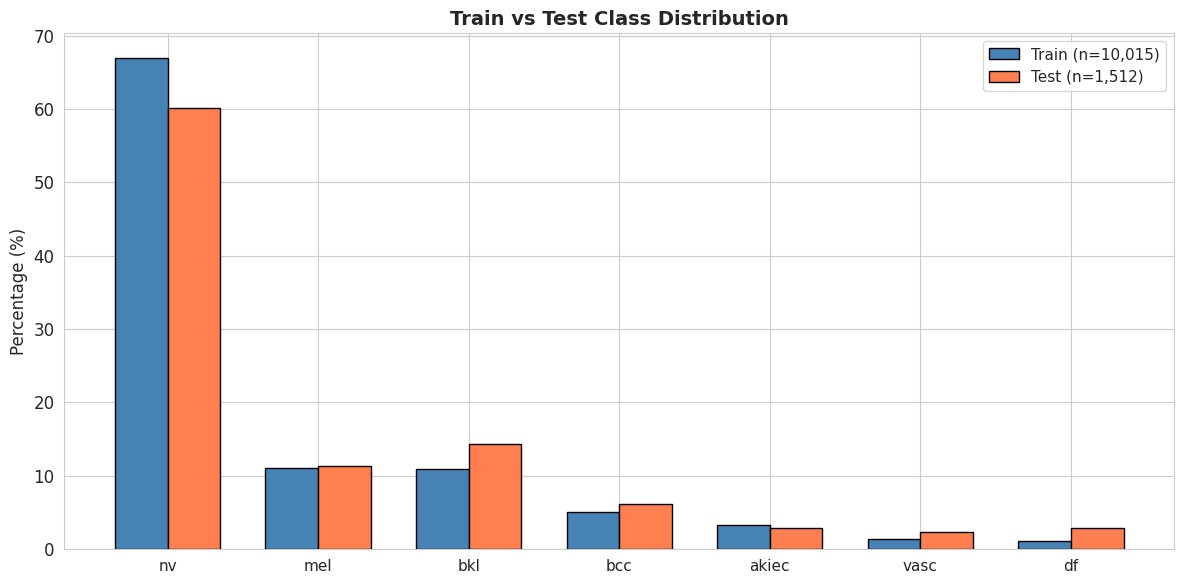


📊 Train vs Test Distribution:
Class         Train %     Test %      Shift
---------------------------------------------
nv              66.9%      60.1% ↓ 6.8%
mel             11.1%      11.3% ↑ 0.2%
bkl             11.0%      14.4% ↑ 3.4%
bcc              5.1%       6.2% ↑ 1.0%
akiec            3.3%       2.8% ↓ 0.4%
vasc             1.4%       2.3% ↑ 0.9%
df               1.1%       2.9% ↑ 1.8%

💡 If distributions differ significantly, the model must handle
   distribution shift. This is common in real medical settings.


In [21]:
# ============================================================================
# CELL 18: Test Set Analysis
# ============================================================================
# RATIONALE: The ISIC 2018 test set provides a real-world evaluation benchmark.
# Comparing train vs test distributions tells us:
#   1. Are they similarly distributed? (If not, our model needs to generalize)
#   2. What demographic shifts exist between train and test?
#   3. Whether we can use this as our held-out evaluation set
# ============================================================================

# Load test ground truth
test_df = pd.read_csv(TEST_GT_PATH)

print(f'📋 Test Set Overview:')
print(f'  Total test images: {len(test_df):,}')
print(f'  Columns: {test_df.columns.tolist()}')
print(f'\n  First 3 rows:')
display(test_df.head(3))

# Test class distribution
test_class_counts = test_df['dx'].value_counts()

# Compare train vs test distribution
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(classes_sorted))
width = 0.35

train_pct = [(class_counts.get(dx, 0) / len(df) * 100) for dx in classes_sorted]
test_pct = [(test_class_counts.get(dx, 0) / len(test_df) * 100) for dx in classes_sorted]

ax.bar(x - width/2, train_pct, width, label=f'Train (n={len(df):,})', color='steelblue', edgecolor='black')
ax.bar(x + width/2, test_pct, width, label=f'Test (n={len(test_df):,})', color='coral', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(classes_sorted, fontsize=11)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Train vs Test Class Distribution', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_train_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Train vs Test Distribution:')
print(f'{"Class":10s} {"Train %":>10s} {"Test %":>10s} {"Shift":>10s}')
print('-' * 45)
for dx in classes_sorted:
    t = class_counts.get(dx, 0) / len(df) * 100
    te = test_class_counts.get(dx, 0) / len(test_df) * 100
    shift = te - t
    arrow = '↑' if shift > 0 else '↓' if shift < 0 else '→'
    print(f'{dx:10s} {t:9.1f}% {te:9.1f}% {arrow} {abs(shift):.1f}%')

print(f'\n💡 If distributions differ significantly, the model must handle')
print(f'   distribution shift. This is common in real medical settings.')

---
## Section 11: Data Source Analysis

HAM10000 combines images from **multiple clinical sources**. Understanding this helps identify:
1. **Domain shift** — Images from different clinics may look different (lighting, equipment)
2. **Source bias** — If one source only contributes melanoma images, the model might learn source-specific artifacts

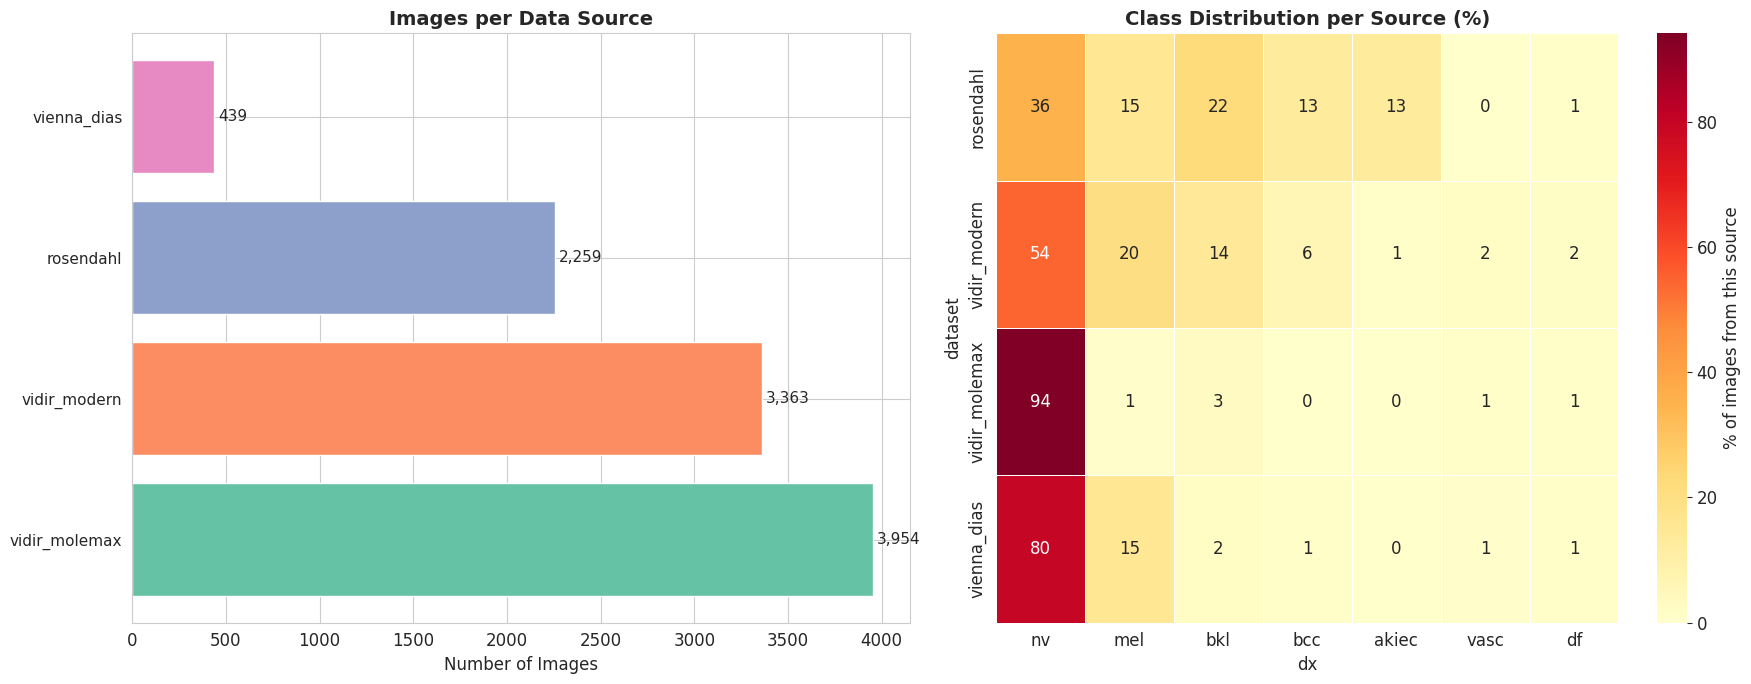


📊 Data Source Summary:
  vidir_molemax: 3,954 images (39.5%)
  vidir_modern: 3,363 images (33.6%)
  rosendahl: 2,259 images (22.6%)
  vienna_dias: 439 images (4.4%)

💡 If one source dominates a specific class, the model might learn
   source-specific artifacts instead of lesion features.
   → Augmentation (color jitter, contrast changes) helps mitigate this.


In [22]:
# ============================================================================
# CELL 19: Data Source Analysis
# ============================================================================
# RATIONALE: HAM10000 comes from different medical institutions. Each may
# use different dermatoscope equipment, lighting, image processing.
# If the model learns to identify the SOURCE instead of the LESION,
# it won't generalize to new clinics.
#
# A stacked bar chart shows which classes come from which sources.
# If melanoma ONLY comes from one source, that's a red flag.
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Subplot 1: Images per source ---
source_counts = df['dataset'].value_counts()
axes[0].barh(range(len(source_counts)), source_counts.values, color=sns.color_palette('Set2'))
axes[0].set_yticks(range(len(source_counts)))
axes[0].set_yticklabels(source_counts.index, fontsize=11)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Images per Data Source', fontsize=14, fontweight='bold')
for i, v in enumerate(source_counts.values):
    axes[0].text(v + 20, i, f'{v:,}', va='center', fontsize=11)

# --- Subplot 2: Source × Class heatmap ---
source_class_cross = pd.crosstab(df['dataset'], df['dx'], normalize='index') * 100
source_class_cross = source_class_cross[class_counts.index]
sns.heatmap(
    source_class_cross, annot=True, fmt='.0f', cmap='YlOrRd',
    ax=axes[1], linewidths=0.5,
    cbar_kws={'label': '% of images from this source'}
)
axes[1].set_title('Class Distribution per Source (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(DATA_DIR.parent / 'eda_data_source.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Data Source Summary:')
for src, count in source_counts.items():
    print(f'  {src}: {count:,} images ({100*count/len(df):.1f}%)')

print(f'\n💡 If one source dominates a specific class, the model might learn')
print(f'   source-specific artifacts instead of lesion features.')
print(f'   → Augmentation (color jitter, contrast changes) helps mitigate this.')

---
## Section 12: Correlation Analysis

Let's check if there are **statistical correlations** between the metadata features. This reveals potential confounding variables.

In [23]:
# ============================================================================
# CELL 20: Correlation Analysis
# ============================================================================
# RATIONALE: We want to find confounding variables — features that correlate
# with the diagnosis but aren't actually diagnostic. For example:
#   - If melanoma patients are always older, the model might learn
#     "old skin texture → melanoma" instead of actual melanoma features.
#   - If one data source mostly has nevi, the model might learn
#     source-specific imaging artifacts.
#
# Since our features are categorical + numeric, we'll use a combination
# of techniques:
#   - Chi-squared test for categorical × categorical
#   - ANOVA for numeric × categorical
# ============================================================================

from scipy import stats

# Age vs Diagnosis (ANOVA)
# RATIONALE: ANOVA tests whether the mean age differs significantly between
# diagnostic classes. If p < 0.05, age and diagnosis are statistically related.
print('📊 Statistical Correlations')
print('=' * 60)

# ANOVA: Age ~ Diagnosis
age_groups = [df[df['dx'] == dx]['age'].dropna().values for dx in classes_sorted]
f_stat, p_value = stats.f_oneway(*age_groups)
print(f'\n  Age vs Diagnosis (ANOVA):')
print(f'    F-statistic: {f_stat:.2f}, p-value: {p_value:.2e}')
print(f'    Significant (p<0.05): {"YES" if p_value < 0.05 else "NO"}')
if p_value < 0.05:
    print(f'    → Age IS statistically associated with diagnosis.')
    print(f'    → This is expected (melanoma occurs more in older patients).')
    print(f'    → But since we only use images (not age), this doesn\'t directly')
    print(f'      affect our model. However, aging skin looks different, so there')
    print(f'      could be a subtle texture-based confound.')

# Chi-squared: Sex × Diagnosis
contingency_sex = pd.crosstab(df['sex'], df['dx'])
chi2, p_sex, dof, expected = stats.chi2_contingency(contingency_sex)
print(f'\n  Sex vs Diagnosis (Chi-squared):')
print(f'    Chi2: {chi2:.2f}, p-value: {p_sex:.2e}')
print(f'    Significant (p<0.05): {"YES" if p_sex < 0.05 else "NO"}')

# Chi-squared: Dataset source × Diagnosis
contingency_src = pd.crosstab(df['dataset'], df['dx'])
chi2_src, p_src, _, _ = stats.chi2_contingency(contingency_src)
print(f'\n  Data Source vs Diagnosis (Chi-squared):')
print(f'    Chi2: {chi2_src:.2f}, p-value: {p_src:.2e}')
print(f'    Significant (p<0.05): {"YES" if p_src < 0.05 else "NO"}')
if p_src < 0.05:
    print(f'    ⚠️ Data source is STRONGLY associated with diagnosis!')
    print(f'    → Some sources contribute specific classes more than others.')
    print(f'    → The model might learn source-specific artifacts.')
    print(f'    → Mitigation: Heavy augmentation + color jitter.')

# Chi-squared: Localization × Diagnosis
contingency_loc = pd.crosstab(df['localization'], df['dx'])
chi2_loc, p_loc, _, _ = stats.chi2_contingency(contingency_loc)
print(f'\n  Localization vs Diagnosis (Chi-squared):')
print(f'    Chi2: {chi2_loc:.2f}, p-value: {p_loc:.2e}')
print(f'    Significant (p<0.05): {"YES" if p_loc < 0.05 else "NO"}')

📊 Statistical Correlations

  Age vs Diagnosis (ANOVA):
    F-statistic: 470.12, p-value: 0.00e+00
    Significant (p<0.05): YES
    → Age IS statistically associated with diagnosis.
    → This is expected (melanoma occurs more in older patients).
    → But since we only use images (not age), this doesn't directly
      affect our model. However, aging skin looks different, so there
      could be a subtle texture-based confound.

  Sex vs Diagnosis (Chi-squared):
    Chi2: 106.90, p-value: 2.45e-17
    Significant (p<0.05): YES

  Data Source vs Diagnosis (Chi-squared):
    Chi2: 3484.06, p-value: 0.00e+00
    Significant (p<0.05): YES
    ⚠️ Data source is STRONGLY associated with diagnosis!
    → Some sources contribute specific classes more than others.
    → The model might learn source-specific artifacts.
    → Mitigation: Heavy augmentation + color jitter.

  Localization vs Diagnosis (Chi-squared):
    Chi2: 2821.91, p-value: 0.00e+00
    Significant (p<0.05): YES


---
## Section 13: Image-Level Integrity Check

Let's verify that every image in the metadata can actually be found on disk, and every image on disk has metadata.

In [24]:
# ============================================================================
# CELL 21: Cross-Reference Images ↔ Metadata
# ============================================================================
# RATIONALE: Data integrity check. If images are missing but metadata exists
# (or vice versa), our DataLoader will crash during training.
# It's MUCH better to find this now than at 3am on epoch 15.
#
# We check:
#   1. Every image_id in metadata has a corresponding file on disk
#   2. Every image file on disk has a corresponding metadata row
#   3. Count any mismatches
# ============================================================================

metadata_ids = set(df['image_id'].tolist())
disk_ids = set(image_path_map.keys())

# Images in metadata but NOT on disk
in_meta_not_disk = metadata_ids - disk_ids
# Images on disk but NOT in metadata
in_disk_not_meta = disk_ids - metadata_ids
# Perfect matches
matched = metadata_ids & disk_ids

print('🔍 Image ↔ Metadata Cross-Reference')
print('=' * 60)
print(f'  Metadata image_ids: {len(metadata_ids):,}')
print(f'  Images on disk:     {len(disk_ids):,}')
print(f'  Matched:            {len(matched):,} ✅')
print(f'  In metadata, not on disk: {len(in_meta_not_disk)} {"❌" if in_meta_not_disk else "✅"}')
print(f'  On disk, not in metadata: {len(in_disk_not_meta)} {"⚠️" if in_disk_not_meta else "✅"}')

if in_meta_not_disk:
    print(f'\n  ❌ Missing images (first 5): {list(in_meta_not_disk)[:5]}')
    print(f'     These rows must be dropped from the DataFrame before training!')
if in_disk_not_meta:
    print(f'\n  ⚠️ Extra images without metadata (first 5): {list(in_disk_not_meta)[:5]}')
    print(f'     These won\'t be used in training (no label). Not a problem.')

# Store the clean DataFrame for training
df_clean = df[df['image_id'].isin(disk_ids)].copy()
print(f'\n  Clean dataset size: {len(df_clean):,} images with both metadata AND files on disk.')

🔍 Image ↔ Metadata Cross-Reference
  Metadata image_ids: 10,015
  Images on disk:     10,015
  Matched:            10,015 ✅
  In metadata, not on disk: 0 ✅
  On disk, not in metadata: 0 ✅

  Clean dataset size: 10,015 images with both metadata AND files on disk.


---
## Section 14: EDA Findings Summary & Training Recommendations

This section consolidates ALL findings from the EDA into **actionable decisions** for the training pipeline.

In [25]:
# ============================================================================
# CELL 22: EDA Findings Summary & Actionable Recommendations
# ============================================================================
# RATIONALE: The entire point of EDA is to inform your training strategy.
# Every finding should map to a concrete decision in your pipeline.
# This cell serves as the "so what?" — connecting analysis to action.
# ============================================================================

print('=' * 70)
print('📋 EDA FINDINGS SUMMARY & TRAINING RECOMMENDATIONS')
print('=' * 70)

print(f'''
┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 1: SEVERE CLASS IMBALANCE                                 │
├─────────────────────────────────────────────────────────────────────┤
│ Largest class (nv): {class_counts.max():,} images ({100*class_counts.max()/len(df):.1f}%)              │
│ Smallest class (df): {class_counts.min():,} images ({100*class_counts.min()/len(df):.1f}%)              │
│ Imbalance ratio: {imbalance_ratio:.0f}:1                                        │
│                                                                     │
│ → ACTION: Use WeightedRandomSampler in DataLoader                 │
│ → ACTION: Use Focal Loss (not standard CrossEntropy)              │
│ → ACTION: Primary metric = Balanced Accuracy (NOT accuracy)       │
│ → ACTION: Track per-class recall, especially for melanoma         │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 2: DUPLICATE LESIONS (DATA LEAKAGE RISK)                  │
├─────────────────────────────────────────────────────────────────────┤
│ Unique lesions: {df['lesion_id'].nunique():,}                                         │
│ Total images: {len(df):,}                                           │
│ Duplicate images: {len(df) - df['lesion_id'].nunique():,} ({100*(len(df) - df['lesion_id'].nunique())/len(df):.1f}% of dataset)                      │
│                                                                     │
│ → ACTION: Use StratifiedGroupKFold (group by lesion_id)           │
│ → ACTION: NEVER split by image_id alone!                          │
│ → This is the #1 mistake in medical imaging research.             │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 3: LABEL QUALITY VARIES                                   │
├─────────────────────────────────────────────────────────────────────┤
│ Histopathology-confirmed: {100*(df['dx_type']=='histo').sum()/len(df):.1f}%                               │
│ Follow-up confirmed: {100*(df['dx_type']=='follow_up').sum()/len(df):.1f}%                                  │
│ Expert consensus: {100*(df['dx_type']=='consensus').sum()/len(df):.1f}%                                     │
│                                                                     │
│ → ACTION: Use label_smoothing=0.1 (softens hard labels)           │
│ → ACTION: Account for potential label noise in evaluation          │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 4: DATA FROM MULTIPLE SOURCES                             │
├─────────────────────────────────────────────────────────────────────┤
│ Number of data sources: {df['dataset'].nunique()}                                       │
│ Source-diagnosis correlation: SIGNIFICANT (p < 0.05)              │
│                                                                     │
│ → ACTION: Strong color/contrast augmentation                      │
│ → ACTION: RandAdjustContrast + RandGaussianSmooth in MONAI        │
│ → ACTION: Ensures model learns lesion features, not source style  │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 5: IMAGE CHARACTERISTICS                                  │
├─────────────────────────────────────────────────────────────────────┤
│ All images are RGB (3-channel)                                     │
│ Consistent dimensions → easy to batch                             │
│ Target size: 224×224 (DINOv2 input)                               │
│                                                                     │
│ → ACTION: Resize(256) + CenterCrop(224) for validation            │
│ → ACTION: Resize(256) + RandomCrop(224) for training              │
│ → ACTION: Use ImageNet normalization (not dataset-specific)       │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 6: TEST SET AVAILABLE                                     │
├─────────────────────────────────────────────────────────────────────┤
│ ISIC 2018 test set: {len(test_df):,} images with ground truth             │
│ Can serve as held-out evaluation benchmark                        │
│                                                                     │
│ → ACTION: Use for final model evaluation after 5-fold CV          │
│ → ACTION: Compare our metrics with published ISIC 2018 results    │
└─────────────────────────────────────────────────────────────────────┘
''')

print('\n🎯 UPDATED TRAINING CONFIGURATION BASED ON EDA:')
print('-' * 50)
print('  batch_size:        32  (fits in Colab GPU memory)')
print('  num_epochs:        30  (with early stopping patience=7)')
print('  learning_rate:     1e-3 (Phase 1), 1e-5 (Phase 2)')
print('  label_smoothing:   0.1  (accounts for label noise)')
print('  loss_function:     Focal Loss (handles class imbalance)')
print('  sampler:           WeightedRandomSampler (balances classes)')
print('  cv_strategy:       StratifiedGroupKFold, 5 folds')
print('  grouping:          group by lesion_id (prevents data leakage)')
print('  primary_metric:    Balanced Accuracy')
print('  normalization:     ImageNet mean/std via MONAI')
print('  augmentation:      RandFlip + RandRotate + RandGaussianSmooth')
print('                     + RandAdjustContrast + RandGaussianNoise')

📋 EDA FINDINGS SUMMARY & TRAINING RECOMMENDATIONS

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 1: SEVERE CLASS IMBALANCE                                 │
├─────────────────────────────────────────────────────────────────────┤
│ Largest class (nv): 6,705 images (66.9%)              │
│ Smallest class (df): 115 images (1.1%)              │
│ Imbalance ratio: 58:1                                        │
│                                                                     │
│ → ACTION: Use WeightedRandomSampler in DataLoader                 │
│ → ACTION: Use Focal Loss (not standard CrossEntropy)              │
│ → ACTION: Primary metric = Balanced Accuracy (NOT accuracy)       │
│ → ACTION: Track per-class recall, especially for melanoma         │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│ FINDING 2: DUPLICATE LESIONS (DATA LEAKAGE RISK)         

---
## Section 15: What To Do Next & Learning Path

Now that you understand the data, here's the **recommended next steps** and WHY each matters.

In [26]:
# ============================================================================
# CELL 23: Learning Roadmap & Next Steps
# ============================================================================
# RATIONALE: After EDA, the next steps are informed by what we found.
# Each step builds on the previous one, and the EDA findings directly
# influence HOW we implement each component.
# ============================================================================

print('''
🎓 LEARNING ROADMAP — What to Do Next (and Why)
{'=' * 60}

STEP 1: Build the Dataset Class (dataset.py)
───────────────────────────────────────────────
WHY NEXT: You now know the data format, class distribution, and leakage risks.
WHAT YOU'LL LEARN:
  • PyTorch Dataset/DataLoader pattern
  • MONAI transforms for medical images
  • StratifiedGroupKFold for leak-free splitting
  • WeightedRandomSampler for class balancing
EDA FINDING APPLIED:
  • Group by lesion_id (from Finding 2)
  • Class weights computed above (from Finding 1)
  • Augmentation choices justified by source analysis (Finding 4)

STEP 2: Build the Model (model.py)
───────────────────────────────────
WHY NEXT: With data loading working, you need a model to feed it into.
WHAT YOU'LL LEARN:
  • How DINOv2 works as a feature extractor
  • Transfer learning: freeze backbone → train head
  • Why LayerNorm + Dropout + Linear is a standard head
EDA FINDING APPLIED:
  • 7 output classes (from class analysis)
  • RGB 3-channel input confirmed (from image analysis)

STEP 3: Build the Training Loop (trainer.py)
─────────────────────────────────────────────
WHY NEXT: This is where learning actually happens.
WHAT YOU'LL LEARN:
  • Focal Loss (and why standard CE fails on imbalanced data)
  • AdamW optimizer (and why it's preferred for ViTs)
  • Cosine annealing LR schedule (and why warmup helps)
  • Early stopping (and why more epochs ≠ better model)
  • W&B logging (and how to read training curves)
EDA FINDING APPLIED:
  • Focal Loss with class weights (from Finding 1)
  • label_smoothing=0.1 (from Finding 3: label quality)
  • Balanced accuracy as metric (from Finding 1)

STEP 4: Build Evaluation (evaluate.py)
───────────────────────────────────────
WHY NEXT: You need to know if the model is actually good.
WHAT YOU'LL LEARN:
  • Confusion matrix interpretation
  • Precision/Recall/F1 (and which matters more for melanoma)
  • ROC-AUC curves
  • 5-fold aggregation (mean ± std)
EDA FINDING APPLIED:
  • Compare with test set (from Finding 6)
  • Per-class analysis (not just overall accuracy)

STEP 5: Confidence Calibration (shared/confidence.py)
──────────────────────────────────────────────────────
WHY NEXT: Final step before deployment.
WHAT YOU'LL LEARN:
  • Temperature scaling
  • Expected Calibration Error (ECE)
  • Why overconfident models are dangerous in medicine

STEP 6: Full Pipeline Integration
──────────────────────────────────
WHY LAST: Connect trained model to SkinAnalysisSkill.
''')

print('\n' + '=' * 60)
print('🏁 EDA COMPLETE — You now understand your data!')
print('   Every decision in the training pipeline is backed by evidence.')
print('=' * 60)


🎓 LEARNING ROADMAP — What to Do Next (and Why)
{'=' * 60}

STEP 1: Build the Dataset Class (dataset.py)
───────────────────────────────────────────────
WHY NEXT: You now know the data format, class distribution, and leakage risks.
WHAT YOU'LL LEARN:
  • PyTorch Dataset/DataLoader pattern
  • MONAI transforms for medical images
  • StratifiedGroupKFold for leak-free splitting
  • WeightedRandomSampler for class balancing
EDA FINDING APPLIED:
  • Group by lesion_id (from Finding 2)
  • Class weights computed above (from Finding 1)
  • Augmentation choices justified by source analysis (Finding 4)

STEP 2: Build the Model (model.py)
───────────────────────────────────
WHY NEXT: With data loading working, you need a model to feed it into.
WHAT YOU'LL LEARN:
  • How DINOv2 works as a feature extractor
  • Transfer learning: freeze backbone → train head
  • Why LayerNorm + Dropout + Linear is a standard head
EDA FINDING APPLIED:
  • 7 output classes (from class analysis)
  • RGB 3-channel in

### ============================================================================
# CELL 23: Save EDA Summary to JSON (for reference during training)
# ============================================================================
# RATIONALE: We save key statistics to a JSON file so that:
#   1. dataset.py can read class weights from it
#   2. We have a record of the data at EDA time
#   3. Other notebooks can reference these numbers
# ============================================================================

import json

eda_summary = {
    'dataset_name': 'HAM10000 / ISIC 2018',
    'eda_date': pd.Timestamp.now().isoformat(),
    'total_images': len(df),
    'total_unique_lesions': int(df['lesion_id'].nunique()),
    'num_classes': int(df['dx'].nunique()),
    'class_distribution': {dx: int(count) for dx, count in class_counts.items()},
    'class_weights': {dx: round(w, 4) for dx, w in class_weights.items()},
    'imbalance_ratio': round(float(imbalance_ratio), 1),
    'duplicate_lesion_images': int(len(df) - df['lesion_id'].nunique()),
    'histopathology_confirmed_pct': round(100 * (df['dx_type'] == 'histo').sum() / len(df), 1),
    'missing_age_pct': round(100 * df['age'].isna().sum() / len(df), 1),
    'test_set_size': len(test_df),
    'image_paths': {
        'part1': str(IMAGES_PART1_DIR),
        'part2': str(IMAGES_PART2_DIR),
        'segmentation': str(SEGMENTATION_DIR),
        'test': str(TEST_IMAGES_DIR),
    },
    'training_recommendations': {
        'cv_strategy': 'StratifiedGroupKFold (group by lesion_id)',
        'loss_function': 'Focal Loss with class weights',
        'sampler': 'WeightedRandomSampler',
        'primary_metric': 'Balanced Accuracy',
        'label_smoothing': 0.1,
        'normalization': 'ImageNet (mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])',
    },
}

eda_path = DATA_DIR.parent / 'eda_summary.json'
with open(eda_path, 'w') as f:
    json.dump(eda_summary, f, indent=2)

print(f'✅ EDA summary saved to: {eda_path}')
print(f'\n📋 Summary contents:')
print(json.dumps(eda_summary, indent=2))